# Regional Error Systematic Decomposition for Cardiac Parameter Identification

## 背景与目标

在心肌力学参数的贝叶斯推断中，**推断误差的空间分布**（哪些区域估计得好、哪些差）与 equifinality 现象密切相关。本 notebook 对 **点估计 (PE)** 和 **MCMC 后验** 两种推断方法进行系统性的区域误差分解分析。

### 为什么不能仅用后验中位数的 MSE 评估 MCMC？

仅取后验中位数（或均值）计算 MSE，**完全丢弃了 MCMC 提供的不确定性信息**，将一个概率预测退化为点估计。这不仅不公平（MCMC 的优势恰在于给出完整后验分布），而且可能得出误导性结论。

### 本 notebook 采用的概率预测评估体系

| 指标 | 含义 | 优势 |
|------|------|------|
| **CRPS** (Continuous Ranked Probability Score) | 评价完整后验分布对真值的预测质量 | Proper scoring rule；同时惩罚偏差和过度不确定 |
| **Calibration Coverage** | 真值落入 X% 可信区间的实际比例 | 检测后验是否可信（过度自信/过度保守） |
| **Interval Score** | 综合惩罚区间宽度和未覆盖 | 同时反映 sharpness 和 calibration |
| **Sharpness** (CI Width) | 后验可信区间的宽度 | 衡量推断的精确程度 |

对于 PE，使用传统 MSE / MAE 评估。PE vs MCMC 的跨方法比较使用 **CRPS**（它在后验退化为点质量时等价于 MAE）。

### 分析内容

1. **误差数据整理与 CSV 导出** — 逐区域 PE MSE + MCMC CRPS
2. **交叉误差矩阵** — 5×5（病变区域 × 推断区域），分别用 PE MSE 和 MCMC CRPS
3. **箱线图** — 按 severity 分组，展示 PE MSE 和 MCMC CRPS 分布
4. **PE vs MCMC 对比** — CRPS scatter, calibration diagram, sharpness 分析
5. **Calibration 深度分析** — 逐区域、逐 severity 的可信区间覆盖率

---
## 0. 环境配置与全局常量

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import Counter
import pickle
import warnings

# ── 出图风格 ──
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

%matplotlib inline

In [2]:
# ══════════════════════════════════════════════════════════════
# 全局常量 — 根据你的实验设计修改此处
# ══════════════════════════════════════════════════════════════

N_REGIONS = 5
PARAMS_PER_REGION = 2
N_PARAMS = N_REGIONS * PARAMS_PER_REGION  # 10
N_SAMPLES = 100

# 解剖区域标签（顺序与参数索引匹配）
# param_0,1 → Anterior | param_2,3 → Inferior | param_4,5 → Lateral
# param_6,7 → Septal   | param_8,9 → Apical
REGION_LABELS = ["Anterior", "Inferior", "Lateral", "Septal", "Apical"]
REGION_LABELS_SHORT = ["Ant", "Inf", "Lat", "Sep", "Apx"]

PARAM_NAMES_PER_REGION = ["a", "b"]
FULL_PARAM_LABELS = [
    f"{REGION_LABELS_SHORT[r]}_{PARAM_NAMES_PER_REGION[p]}"
    for r in range(N_REGIONS)
    for p in range(PARAMS_PER_REGION)
]

# Scenario 配置
SCENARIOS = ["HCM", "MI_1", "MI_2", "MI_3"]
SCENARIO_TO_FOLDER = {
    "HCM":  "MVGP_HCM",
    "MI_1": "MVGP_MI_1",
    "MI_2": "MVGP_MI_2",
    "MI_3": "MVGP_MI_3",
}
SCENARIO_DISPLAY = {
    "HCM":  "HCM (Global, \u03bc=1.7)",
    "MI_1": "MI Mild (\u03bc=1.5)",
    "MI_2": "MI Moderate (\u03bc=2.0)",
    "MI_3": "MI Severe (\u03bc=3.0)",
}
LOCAL_MI_SCENARIOS = ["MI_1", "MI_2", "MI_3"]
SAMPLES_PER_TARGET = 20

# Calibration 分析使用的可信水平
CREDIBLE_LEVELS = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

# ══════════════════════════════════════════════════════════════
# 数据文件路径映射
# ══════════════════════════════════════════════════════════════

# 真值 CSV (100×10)
TRUTH_CSV = {
    "HCM":  "LocalDisease/X_HCM.csv",
    "MI_1": "LocalDisease/X_MI_1_5.csv",
    "MI_2": "LocalDisease/X_MI_2.csv",
    "MI_3": "LocalDisease/X_MI_3.csv",
}

# 点估计 CSV (100×10)
PE_CSV = {
    "HCM":  "LocalDisease/Result/PE_result/PE_HCM_result.csv",
    "MI_1": "LocalDisease/Result/PE_result/PE_MI_1_result.csv",
    "MI_2": "LocalDisease/Result/PE_result/PE_MI_2_result.csv",
    "MI_3": "LocalDisease/Result/PE_result/PE_MI_3_result.csv",
}

# MCMC 结果路径 (pkl files)
DATA_ROOT = "LocalDisease/Result"

# 输出目录
OUTPUT_DIR = "LocalDisease/figures_error"
CSV_DIR = "LocalDisease/csv_results"

for d in [OUTPUT_DIR, CSV_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")
print(f"Regions: {REGION_LABELS}")
print(f"Parameters per region: {PARAMS_PER_REGION} → {N_PARAMS} total")
print(f"Scenarios: {SCENARIOS}")
print(f"Credible levels for calibration: {CREDIBLE_LEVELS}")

Configuration loaded.
Regions: ['Anterior', 'Inferior', 'Lateral', 'Septal', 'Apical']
Parameters per region: 2 → 10 total
Scenarios: ['HCM', 'MI_1', 'MI_2', 'MI_3']
Credible levels for calibration: [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]


---
## 1. 数据加载

### 数据格式

| 数据类型 | 格式 | 尺寸 | 说明 |
|----------|------|------|------|
| **真值** | CSV | 100×10 | `X_HCM.csv`, `X_MI_1_5.csv`, `X_MI_2.csv`, `X_MI_3.csv` |
| **点估计** | CSV | 100×10 | `PE_result/PE_{scenario}_result.csv` |
| **MCMC chain** | pkl | (n_mcmc, 10) | `MVGP_{scenario}_mcmc_result/result_{idx}.pkl` |

对 MCMC，需要保留**完整的后验 chain**（不是中位数/均值的点压缩），因为后续的 CRPS、calibration、interval score 计算都依赖完整后验样本。

### 输出目的

确认所有数据文件完整性，打印加载概况。

In [3]:
def get_target_region(sample_idx_1based: int) -> int:
    """
    根据 1-based 的样本编号推断病变区域。
    Samples 1-20 → Region 0 (Anterior)  ...  Samples 81-100 → Region 4 (Apical)
    """
    return (sample_idx_1based - 1) // SAMPLES_PER_TARGET


def mcmc_dict_to_array(chain_dict: dict) -> np.ndarray:
    """将单条 MCMC chain 从字典格式转为 (n_mcmc, 10) 的 numpy 矩阵。"""
    arrays = []
    for i in range(N_PARAMS):
        t = chain_dict[f"param_{i}"]
        if hasattr(t, "cpu"):
            arrays.append(t.cpu().numpy())
        else:
            arrays.append(np.asarray(t))
    return np.column_stack(arrays)


def load_truth_values(scenario: str) -> np.ndarray:
    """从 CSV 加载真值参数。返回 (100, 10) ndarray。"""
    csv_path = Path(TRUTH_CSV[scenario])
    if not csv_path.exists():
        raise FileNotFoundError(f"Truth CSV not found: {csv_path}")
    df = pd.read_csv(csv_path, header=None)
    assert df.shape == (N_SAMPLES, N_PARAMS), \
        f"Expected ({N_SAMPLES}, {N_PARAMS}), got {df.shape} for {csv_path}"
    return df.values


def load_point_estimates(scenario: str) -> np.ndarray:
    """从 CSV 加载点估计结果。返回 (100, 10) ndarray。"""
    csv_path = Path(PE_CSV[scenario])
    if not csv_path.exists():
        raise FileNotFoundError(f"Point estimate CSV not found: {csv_path}")
    df = pd.read_csv(csv_path, header=None)
    assert df.shape == (N_SAMPLES, N_PARAMS), \
        f"Expected ({N_SAMPLES}, {N_PARAMS}), got {df.shape} for {csv_path}"
    return df.values


def load_mcmc_chains(scenario: str) -> List[np.ndarray]:
    """
    加载完整 MCMC chains（不压缩为中位数/均值）。
    
    返回 list of (n_mcmc, 10) arrays, 长度 = 100。
    保留完整 chain 是计算 CRPS、calibration 等概率指标的前提。
    """
    root = Path(DATA_ROOT)
    folder_name = f"{SCENARIO_TO_FOLDER[scenario]}_mcmc_result"
    folder_path = root / folder_name
    
    if not folder_path.exists():
        raise FileNotFoundError(f"MCMC folder not found: {folder_path}")
    
    chains = []
    for idx in range(1, N_SAMPLES + 1):
        pkl_path = folder_path / f"result_{idx}.pkl"
        if not pkl_path.exists():
            print(f"  WARNING: missing {pkl_path}")
            chains.append(None)
            continue
        with open(pkl_path, "rb") as f:
            chains.append(mcmc_dict_to_array(pickle.load(f)))
    
    n_loaded = sum(1 for c in chains if c is not None)
    chain_len = next((c.shape[0] for c in chains if c is not None), "?")
    print(f"    Chains loaded: {n_loaded}/{N_SAMPLES}, chain length = {chain_len}")
    return chains

In [4]:
# ══════════════════════════════════════════════════════════════
# 执行加载
# ══════════════════════════════════════════════════════════════
all_truths = {}       # scenario → (100, 10)
all_point_ests = {}   # scenario → (100, 10)
all_chains = {}       # scenario → list of 100 × (n_mcmc, 10) arrays
all_targets = {}      # scenario → list of int/None, length 100

for scenario in SCENARIOS:
    print(f"\n{'='*60}")
    print(f"Loading {scenario} ({SCENARIO_DISPLAY[scenario]})")
    print(f"{'='*60}")
    
    truths = load_truth_values(scenario)
    all_truths[scenario] = truths
    print(f"  ✅ Truth:  {truths.shape}  from {TRUTH_CSV[scenario]}")
    
    pe = load_point_estimates(scenario)
    all_point_ests[scenario] = pe
    print(f"  ✅ PE:     {pe.shape}  from {PE_CSV[scenario]}")
    
    print(f"  ⏳ Loading MCMC chains (full posterior)...")
    chains = load_mcmc_chains(scenario)
    all_chains[scenario] = chains
    
    targets = [
        get_target_region(idx + 1) if scenario in LOCAL_MI_SCENARIOS else None
        for idx in range(N_SAMPLES)
    ]
    all_targets[scenario] = targets
    
    if scenario in LOCAL_MI_SCENARIOS:
        dist = Counter(targets)
        print(f"  Target distribution: "
              + ", ".join(f"{REGION_LABELS[r]}={dist[r]}" for r in sorted(dist)))

print(f"\n{'='*60}")
print("All data loaded successfully.")


Loading HCM (HCM (Global, μ=1.7))
  ✅ Truth:  (100, 10)  from LocalDisease/X_HCM.csv
  ✅ PE:     (100, 10)  from LocalDisease/Result/PE_result/PE_HCM_result.csv
  ⏳ Loading MCMC chains (full posterior)...
    Chains loaded: 100/100, chain length = 1200

Loading MI_1 (MI Mild (μ=1.5))
  ✅ Truth:  (100, 10)  from LocalDisease/X_MI_1_5.csv
  ✅ PE:     (100, 10)  from LocalDisease/Result/PE_result/PE_MI_1_result.csv
  ⏳ Loading MCMC chains (full posterior)...
    Chains loaded: 100/100, chain length = 1200
  Target distribution: Anterior=20, Inferior=20, Lateral=20, Septal=20, Apical=20

Loading MI_2 (MI Moderate (μ=2.0))
  ✅ Truth:  (100, 10)  from LocalDisease/X_MI_2.csv
  ✅ PE:     (100, 10)  from LocalDisease/Result/PE_result/PE_MI_2_result.csv
  ⏳ Loading MCMC chains (full posterior)...
    Chains loaded: 100/100, chain length = 1200
  Target distribution: Anterior=20, Inferior=20, Lateral=20, Septal=20, Apical=20

Loading MI_3 (MI Severe (μ=3.0))
  ✅ Truth:  (100, 10)  from LocalDis

---
## 2. 概率预测评估指标定义

### 核心指标

#### CRPS (Continuous Ranked Probability Score)

CRPS 是评价概率预测的 **proper scoring rule**（不可通过错误的预测取巧获得更好分数）。对后验样本 $\{x_1, \dots, x_M\}$ 和真值 $y$：

$$\text{CRPS}(F, y) = \frac{1}{M}\sum_{i=1}^{M}|x_i - y| - \frac{1}{2M^2}\sum_{i=1}^{M}\sum_{j=1}^{M}|x_i - x_j|$$

第一项惩罚后验偏离真值（**accuracy**），第二项奖励后验集中（**sharpness**）。  
关键性质：当后验退化为点质量 $\delta_{\hat{x}}$ 时，CRPS = $|\hat{x} - y|$ = MAE，因此可以公平地与点估计比较。

#### Calibration Coverage

对给定可信水平 $\alpha$，检查真值是否落入 $\alpha$ 可信区间：

$$\text{Coverage}(\alpha) = \frac{1}{N}\sum_{i=1}^{N} \mathbb{1}\left[y_i \in \text{CI}_{\alpha}(F_i)\right]$$

理想情况下 Coverage($\alpha$) $\approx \alpha$。过低 → 后验过度自信，过高 → 过度保守。

#### Interval Score

同时惩罚区间过宽和未覆盖（$\alpha$ 水平下）：

$$\text{IS}_{\alpha}(l, u, y) = (u - l) + \frac{2}{1-\alpha}(l - y)^+ + \frac{2}{1-\alpha}(y - u)^+$$

#### Sharpness (CI Width)

$$\text{Width}_{\alpha} = q_{(1+\alpha)/2} - q_{(1-\alpha)/2}$$

更窄的可信区间表示更精确的推断（前提是 calibration 合理）。

In [5]:
# ══════════════════════════════════════════════════════════════
# 概率预测评估核心函数
# ══════════════════════════════════════════════════════════════

def crps_empirical(posterior_samples: np.ndarray, truth: float) -> float:
    """
    计算单个参数的 empirical CRPS。
    
    Parameters
    ----------
    posterior_samples : (M,) — MCMC 后验样本
    truth : scalar — 真实值
    
    Returns
    -------
    crps : float — 越小越好
    
    公式: CRPS = E|X - y| - 0.5 * E|X - X'|
    使用排序优化，复杂度 O(M log M) 而非 O(M²)
    """
    M = len(posterior_samples)
    sorted_samples = np.sort(posterior_samples)
    
    # E|X - y|
    mae_term = np.mean(np.abs(sorted_samples - truth))
    
    # E|X - X'| via sorted samples: = (2/M²) * Σ_i (2i - M - 1) * x_(i)
    indices = np.arange(1, M + 1)
    spread_term = (2.0 / (M * M)) * np.sum((2 * indices - M - 1) * sorted_samples)
    
    return mae_term - 0.5 * spread_term


def credible_interval(posterior_samples: np.ndarray, level: float) -> Tuple[float, float]:
    """
    计算对称可信区间 (equal-tail interval)。
    
    Parameters
    ----------
    posterior_samples : (M,) — MCMC 后验样本
    level : float in (0, 1) — 可信水平，如 0.90
    
    Returns
    -------
    (lower, upper) — CI 边界
    """
    alpha = 1 - level
    lower = np.percentile(posterior_samples, 100 * alpha / 2)
    upper = np.percentile(posterior_samples, 100 * (1 - alpha / 2))
    return lower, upper


def interval_score(posterior_samples: np.ndarray, truth: float, level: float) -> float:
    """
    计算 Interval Score — 综合惩罚宽度和未覆盖。
    
    IS_α = (u - l) + (2/(1-α)) * max(l - y, 0) + (2/(1-α)) * max(y - u, 0)
    """
    alpha = 1 - level
    lower, upper = credible_interval(posterior_samples, level)
    width = upper - lower
    penalty = 2.0 / alpha
    
    score = width
    if truth < lower:
        score += penalty * (lower - truth)
    elif truth > upper:
        score += penalty * (truth - upper)
    
    return score


def ci_width(posterior_samples: np.ndarray, level: float) -> float:
    """可信区间宽度 (sharpness)。"""
    lower, upper = credible_interval(posterior_samples, level)
    return upper - lower


def coverage_check(posterior_samples: np.ndarray, truth: float, level: float) -> bool:
    """检查真值是否落入可信区间。"""
    lower, upper = credible_interval(posterior_samples, level)
    return lower <= truth <= upper

In [6]:
def compute_region_metrics_pe(estimate_10d: np.ndarray, truth_10d: np.ndarray) -> Dict:
    """
    点估计的区域级误差指标。
    
    Returns dict with keys: mse_per_region (5,), mae_per_region (5,)
    """
    diff = estimate_10d - truth_10d
    sq = diff ** 2
    ab = np.abs(diff)
    
    mse = np.array([np.mean(sq[r*2:(r+1)*2]) for r in range(N_REGIONS)])
    mae = np.array([np.mean(ab[r*2:(r+1)*2]) for r in range(N_REGIONS)])
    
    return {"mse": mse, "mae": mae}


def compute_region_metrics_mcmc(chain: np.ndarray, truth_10d: np.ndarray,
                                 ci_level: float = 0.90) -> Dict:
    """
    MCMC 后验的区域级概率评估指标。
    
    对每个区域的每个参数计算 CRPS/IS/width/coverage，再取区域内均值。
    
    Parameters
    ----------
    chain    : (n_mcmc, 10) — 完整后验 chain
    truth_10d: (10,)        — 真实值
    ci_level : float        — Interval Score 和 CI Width 使用的可信水平
    
    Returns
    -------
    dict with keys:
        crps_per_region      : (5,) — 区域平均 CRPS
        is_per_region        : (5,) — 区域平均 Interval Score
        width_per_region     : (5,) — 区域平均 CI Width
        coverage_per_region  : (5,) — 区域内参数的覆盖率 (0, 0.5, 或 1)
        median_mse_per_region: (5,) — 后验中位数的 MSE (供参考)
        coverage_all_levels  : (5, n_levels) — 多水平覆盖
    """
    crps_r = np.zeros(N_REGIONS)
    is_r = np.zeros(N_REGIONS)
    width_r = np.zeros(N_REGIONS)
    cov_r = np.zeros(N_REGIONS)
    med_mse_r = np.zeros(N_REGIONS)
    cov_all = np.zeros((N_REGIONS, len(CREDIBLE_LEVELS)))
    
    for r in range(N_REGIONS):
        param_crps = []
        param_is = []
        param_width = []
        param_cov = []
        param_med_sq = []
        param_cov_all = []
        
        for p in range(PARAMS_PER_REGION):
            pidx = r * PARAMS_PER_REGION + p
            samples = chain[:, pidx]
            y = truth_10d[pidx]
            
            param_crps.append(crps_empirical(samples, y))
            param_is.append(interval_score(samples, y, ci_level))
            param_width.append(ci_width(samples, ci_level))
            param_cov.append(float(coverage_check(samples, y, ci_level)))
            param_med_sq.append((np.median(samples) - y) ** 2)
            param_cov_all.append([float(coverage_check(samples, y, lv)) for lv in CREDIBLE_LEVELS])
        
        crps_r[r] = np.mean(param_crps)
        is_r[r] = np.mean(param_is)
        width_r[r] = np.mean(param_width)
        cov_r[r] = np.mean(param_cov)
        med_mse_r[r] = np.mean(param_med_sq)
        cov_all[r] = np.mean(param_cov_all, axis=0)
    
    return {
        "crps": crps_r,
        "interval_score": is_r,
        "ci_width": width_r,
        "coverage": cov_r,
        "median_mse": med_mse_r,
        "coverage_all_levels": cov_all,
    }

---
## 3. 误差数据整理与 CSV 导出

### 计算内容

对每个 (scenario, sample, region) 组合计算 PE 和 MCMC 指标，**同时标注每个区域的角色**：

| 角色标签 | 含义 | 适用场景 |
|----------|------|----------|
| **Diseased** | 病变区域自身 | MI 场景，每 sample 恰好 1 个 |
| **Non-diseased** | 非病变区域 | MI 场景，每 sample 4 个 |
| **Global** | 全局（HCM 场景所有区域均匀病变） | HCM 场景 |

### 聚合记录

除了逐区域的记录外，每个 sample 额外生成三条**聚合记录**：

| 聚合类型 | 定义 | 意义 |
|----------|------|------|
| **Diseased Avg** | 病变区域的指标（= 该区域值本身） | 病变参数的推断精度 |
| **Non-diseased Avg** | 4 个非病变区域指标的均值 | 推断对非病变区域的"溢出"误差 |
| **Overall Avg** | 所有 5 个区域（10 个参数）指标的均值 | 全局推断质量 |

In [7]:
# ══════════════════════════════════════════════════════════════
# 计算所有误差指标 + region_role 标注 + 聚合记录
# ══════════════════════════════════════════════════════════════
CI_LEVEL_MAIN = 0.90

records = []            # 逐区域记录
agg_records = []        # 聚合记录 (diseased avg / non-diseased avg / overall avg)
calibration_records = []

for scenario in SCENARIOS:
    print(f"Computing metrics for {scenario}...")
    truths = all_truths[scenario]
    pe = all_point_ests[scenario]
    chains = all_chains[scenario]
    targets = all_targets[scenario]
    
    for sample_idx in range(N_SAMPLES):
        truth = truths[sample_idx]
        target = targets[sample_idx]
        target_name = REGION_LABELS[target] if target is not None else "Global"
        target_idx = target if target is not None else -1
        
        # ── PE metrics (per-region) ──
        pe_metrics = compute_region_metrics_pe(pe[sample_idx], truth)
        
        # ── MCMC metrics (per-region) ──
        chain = chains[sample_idx]
        mcmc_metrics = None
        if chain is not None:
            mcmc_metrics = compute_region_metrics_mcmc(chain, truth, ci_level=CI_LEVEL_MAIN)
        
        # ── 确定每个区域的 role ──
        for r in range(N_REGIONS):
            if target is None:
                region_role = "Global"
            elif r == target:
                region_role = "Diseased"
            else:
                region_role = "Non-diseased"
            
            base = {
                "scenario": scenario,
                "scenario_display": SCENARIO_DISPLAY[scenario],
                "sample_idx": sample_idx,
                "target_region": target_name,
                "target_region_idx": target_idx,
                "inferred_region": REGION_LABELS[r],
                "inferred_region_idx": r,
                "region_role": region_role,
            }
            
            # PE record
            records.append({
                **base,
                "method": "Point Estimate",
                "mse": pe_metrics["mse"][r],
                "mae": pe_metrics["mae"][r],
                "crps": pe_metrics["mae"][r],
                "interval_score": np.nan,
                "ci_width": 0.0,
                "coverage": np.nan,
                "median_mse": pe_metrics["mse"][r],
            })
            
            # MCMC record
            if mcmc_metrics is not None:
                records.append({
                    **base,
                    "method": "MCMC",
                    "mse": mcmc_metrics["median_mse"][r],
                    "mae": np.nan,
                    "crps": mcmc_metrics["crps"][r],
                    "interval_score": mcmc_metrics["interval_score"][r],
                    "ci_width": mcmc_metrics["ci_width"][r],
                    "coverage": mcmc_metrics["coverage"][r],
                    "median_mse": mcmc_metrics["median_mse"][r],
                })
                
                # Calibration records
                for lv_idx, lv in enumerate(CREDIBLE_LEVELS):
                    calibration_records.append({
                        "scenario": scenario,
                        "sample_idx": sample_idx,
                        "target_region_idx": target_idx,
                        "inferred_region": REGION_LABELS[r],
                        "inferred_region_idx": r,
                        "region_role": region_role,
                        "credible_level": lv,
                        "covered": mcmc_metrics["coverage_all_levels"][r, lv_idx],
                    })
        
        # ══════════════════════════════════════════════════════
        # 聚合记录: Diseased Avg / Non-diseased Avg / Overall Avg
        # ══════════════════════════════════════════════════════
        agg_base = {
            "scenario": scenario,
            "scenario_display": SCENARIO_DISPLAY[scenario],
            "sample_idx": sample_idx,
            "target_region": target_name,
            "target_region_idx": target_idx,
        }
        
        if target is not None:
            # MI scenario: separate diseased / non-diseased
            diseased_idx = [target]
            non_diseased_idx = [r for r in range(N_REGIONS) if r != target]
        else:
            # HCM: all regions are "global", no diseased/non-diseased split
            diseased_idx = []
            non_diseased_idx = []
        
        all_idx = list(range(N_REGIONS))
        
        # Define aggregation groups
        agg_groups = [("Overall Avg", all_idx)]
        if target is not None:
            agg_groups.append(("Diseased Avg", diseased_idx))
            agg_groups.append(("Non-diseased Avg", non_diseased_idx))
        
        for agg_name, region_indices in agg_groups:
            if len(region_indices) == 0:
                continue
            
            # PE aggregate
            agg_records.append({
                **agg_base,
                "aggregate_type": agg_name,
                "method": "Point Estimate",
                "mse": np.mean(pe_metrics["mse"][region_indices]),
                "mae": np.mean(pe_metrics["mae"][region_indices]),
                "crps": np.mean(pe_metrics["mae"][region_indices]),
                "interval_score": np.nan,
                "ci_width": 0.0,
                "coverage": np.nan,
            })
            
            # MCMC aggregate
            if mcmc_metrics is not None:
                agg_records.append({
                    **agg_base,
                    "aggregate_type": agg_name,
                    "method": "MCMC",
                    "mse": np.mean(mcmc_metrics["median_mse"][region_indices]),
                    "mae": np.nan,
                    "crps": np.mean(mcmc_metrics["crps"][region_indices]),
                    "interval_score": np.mean(mcmc_metrics["interval_score"][region_indices]),
                    "ci_width": np.mean(mcmc_metrics["ci_width"][region_indices]),
                    "coverage": np.mean(mcmc_metrics["coverage"][region_indices]),
                })

df_errors = pd.DataFrame(records)
df_agg = pd.DataFrame(agg_records)
df_calib = pd.DataFrame(calibration_records)

print(f"\n✅ Per-region DataFrame: {len(df_errors)} rows")
print(f"✅ Aggregate DataFrame:  {len(df_agg)} rows")
print(f"✅ Calibration DataFrame: {len(df_calib)} rows")
print(f"   region_role values: {df_errors['region_role'].unique().tolist()}")
print(f"   aggregate_type values: {df_agg['aggregate_type'].unique().tolist()}")
df_errors.head(10)

Computing metrics for HCM...
Computing metrics for MI_1...
Computing metrics for MI_2...
Computing metrics for MI_3...

✅ Per-region DataFrame: 4000 rows
✅ Aggregate DataFrame:  2000 rows
✅ Calibration DataFrame: 12000 rows
   region_role values: ['Global', 'Diseased', 'Non-diseased']
   aggregate_type values: ['Overall Avg', 'Diseased Avg', 'Non-diseased Avg']


,scenario,scenario_display,sample_idx,target_region,target_region_idx,inferred_region,inferred_region_idx,region_role,method,mse,mae,crps,interval_score,ci_width,coverage,median_mse
0,HCM,"HCM (Global, μ=1.7)",0,Global,-1,Anterior,0,Global,Point Estimate,0.005832,0.075864,0.075864,NaN,0.000000,NaN,0.005832
1,HCM,"HCM (Global, μ=1.7)",0,Global,-1,Anterior,0,Global,MCMC,0.000814,NaN,0.072843,0.984756,0.984756,1.0,0.000814
2,HCM,"HCM (Global, μ=1.7)",0,Global,-1,Inferior,1,Global,Point Estimate,0.218405,0.460601,0.460601,NaN,0.000000,NaN,0.218405
3,HCM,"HCM (Global, μ=1.7)",0,Global,-1,Inferior,1,Global,MCMC,0.010653,NaN,0.111257,1.498845,1.498845,1.0,0.010653
4,HCM,"HCM (Global, μ=1.7)",0,Global,-1,Lateral,2,Global,Point Estimate,0.005297,0.072387,0.072387,NaN,0.000000,NaN,0.005297
5,HCM,"HCM (Global, μ=1.7)",0,Global,-1,Lateral,2,Global,MCMC,0.000045,NaN,0.045183,0.642030,0.642030,1.0,0.000045
6,HCM,"HCM (Global, μ=1.7)",0,Global,-1,Septal,3,Global,Point Estimate,0.022080,0.145338,0.145338,NaN,0.000000,NaN,0.022080
7,HCM,"HCM (Global, μ=1.7)",0,Global,-1,Septal,3,Global,MCMC,0.047774,NaN,0.147525,1.355235,1.355235,1.0,0.047774
8,HCM,"HCM (Global, μ=1.7)",0,Global,-1,Apical,4,Global,Point Estimate,0.000188,0.010724,0.010724,NaN,0.000000,NaN,0.000188
9,HCM,"HCM (Global, μ=1.7)",0,Global,-1,Apical,4,Global,MCMC,0.000013,NaN,0.042034,0.589208,0.589208,1.0,0.000013


In [8]:
# ══════════════════════════════════════════════════════════════
# 导出 CSV
# ══════════════════════════════════════════════════════════════

# 1) 汇总
df_errors.to_csv(Path(CSV_DIR) / "all_region_errors.csv", index=False, float_format="%.6f")
print(f"✅ Per-region CSV: {CSV_DIR}/all_region_errors.csv  ({len(df_errors)} rows)")

df_agg.to_csv(Path(CSV_DIR) / "aggregate_errors.csv", index=False, float_format="%.6f")
print(f"✅ Aggregate CSV:  {CSV_DIR}/aggregate_errors.csv  ({len(df_agg)} rows)")

# 2) Per-scenario PE
print("\n── Per-Scenario Point Estimate CSVs ──")
for scenario in SCENARIOS:
    df_sc = df_errors[(df_errors["scenario"] == scenario) & (df_errors["method"] == "Point Estimate")]
    if len(df_sc) > 0:
        csv_path = Path(CSV_DIR) / f"pe_errors_{scenario}.csv"
        df_sc.to_csv(csv_path, index=False, float_format="%.6f")
        print(f"  📄 {csv_path.name}: {len(df_sc)} rows")

# 3) Per-scenario MCMC
print("\n── Per-Scenario MCMC CSVs ──")
for scenario in SCENARIOS:
    df_sc = df_errors[(df_errors["scenario"] == scenario) & (df_errors["method"] == "MCMC")]
    if len(df_sc) > 0:
        csv_path = Path(CSV_DIR) / f"mcmc_errors_{scenario}.csv"
        df_sc.to_csv(csv_path, index=False, float_format="%.6f")
        print(f"  📄 {csv_path.name}: {len(df_sc)} rows")

# 4) Calibration
df_calib.to_csv(Path(CSV_DIR) / "calibration_coverage.csv", index=False, float_format="%.6f")
print(f"\n✅ Calibration CSV: {CSV_DIR}/calibration_coverage.csv  ({len(df_calib)} rows)")

✅ Per-region CSV: LocalDisease/csv_results/all_region_errors.csv  (4000 rows)
✅ Aggregate CSV:  LocalDisease/csv_results/aggregate_errors.csv  (2000 rows)

── Per-Scenario Point Estimate CSVs ──
  📄 pe_errors_HCM.csv: 500 rows
  📄 pe_errors_MI_1.csv: 500 rows
  📄 pe_errors_MI_2.csv: 500 rows
  📄 pe_errors_MI_3.csv: 500 rows

── Per-Scenario MCMC CSVs ──
  📄 mcmc_errors_HCM.csv: 500 rows
  📄 mcmc_errors_MI_1.csv: 500 rows
  📄 mcmc_errors_MI_2.csv: 500 rows
  📄 mcmc_errors_MI_3.csv: 500 rows

✅ Calibration CSV: LocalDisease/csv_results/calibration_coverage.csv  (12000 rows)


In [9]:
# ── 汇总统计: 分 region_role 展示 ──
print("Per-Scenario Summary by Region Role")
print("=" * 80)

for scenario in SCENARIOS:
    print(f"\n{'─'*80}")
    print(f"  {SCENARIO_DISPLAY[scenario]}")
    print(f"{'─'*80}")
    
    for method, metric, label in [("Point Estimate", "mse", "MSE"),
                                    ("MCMC", "crps", "CRPS")]:
        df_sc = df_errors[(df_errors["scenario"] == scenario) & (df_errors["method"] == method)]
        if len(df_sc) == 0:
            continue
        
        role_summary = df_sc.groupby("region_role")[metric].agg(["mean", "std", "count"])
        print(f"\n  {method} — {label} by Region Role:")
        print(role_summary.to_string(float_format=lambda x: f"    {x:.4f}"))
    
    # Aggregate summary
    df_agg_sc = df_agg[df_agg["scenario"] == scenario]
    if len(df_agg_sc) > 0:
        print(f"\n  Aggregate Means:")
        for method in ["Point Estimate", "MCMC"]:
            df_m = df_agg_sc[df_agg_sc["method"] == method]
            metric = "mse" if method == "Point Estimate" else "crps"
            label = "MSE" if method == "Point Estimate" else "CRPS"
            if len(df_m) > 0:
                agg_summary = df_m.groupby("aggregate_type")[metric].agg(["mean", "std"])
                print(f"    {method} — {label}:")
                for atype in ["Diseased Avg", "Non-diseased Avg", "Overall Avg"]:
                    if atype in agg_summary.index:
                        m, s = agg_summary.loc[atype, "mean"], agg_summary.loc[atype, "std"]
                        print(f"      {atype:<20} {m:.4f} ± {s:.4f}")

Per-Scenario Summary by Region Role

────────────────────────────────────────────────────────────────────────────────
  HCM (Global, μ=1.7)
────────────────────────────────────────────────────────────────────────────────

  Point Estimate — MSE by Region Role:
                  mean        std  count
region_role                             
Global          0.0376     0.0671    500

  MCMC — CRPS by Region Role:
                  mean        std  count
region_role                             
Global          0.0876     0.0378    500

  Aggregate Means:
    Point Estimate — MSE:
      Overall Avg          0.0376 ± 0.0104
    MCMC — CRPS:
      Overall Avg          0.0876 ± 0.0053

────────────────────────────────────────────────────────────────────────────────
  MI Mild (μ=1.5)
────────────────────────────────────────────────────────────────────────────────

  Point Estimate — MSE by Region Role:
                   mean        std  count
region_role                              
Diseased

---
## 4. 病变区域 vs 非病变区域 vs 全局误差分解

### 分析动机

在 MI 场景中，仅关注病变区域的参数估计误差是不够的。equifinality 意味着**病变区域的参数变化可以被非病变区域的补偿性变化所"吸收"**，因此：

- 即使病变区域的推断误差较小，非病变区域可能因为补偿效应而产生**虚假偏移**
- 即使病变区域难以精确定位，全局推断质量可能仍然可接受（因为补偿后整体力学响应匹配）

### 三个视角

| 视角 | 含义 | 关键问题 |
|------|------|----------|
| **Diseased** | 病变区域自身的推断误差 | 能否准确定位病变参数？ |
| **Non-diseased** | 4 个非病变区域的平均推断误差 | 推断是否"污染"了健康区域？ |
| **Overall** | 所有 10 个参数的平均推断误差 | 全局推断质量如何？ |

### 预期模式

- **理想情况**: Diseased 高，Non-diseased 低，Overall 适中 → 误差集中在病变区域，非病变区域未受污染
- **equifinality 严重**: Diseased 和 Non-diseased 都高 → 补偿效应导致全局"均匀"偏移
- **定位失败**: Diseased 低但 Non-diseased 高 → 推断"跑偏"到错误的区域

💾 Saved: LocalDisease\figures_error\bar_role_pe_mse.png


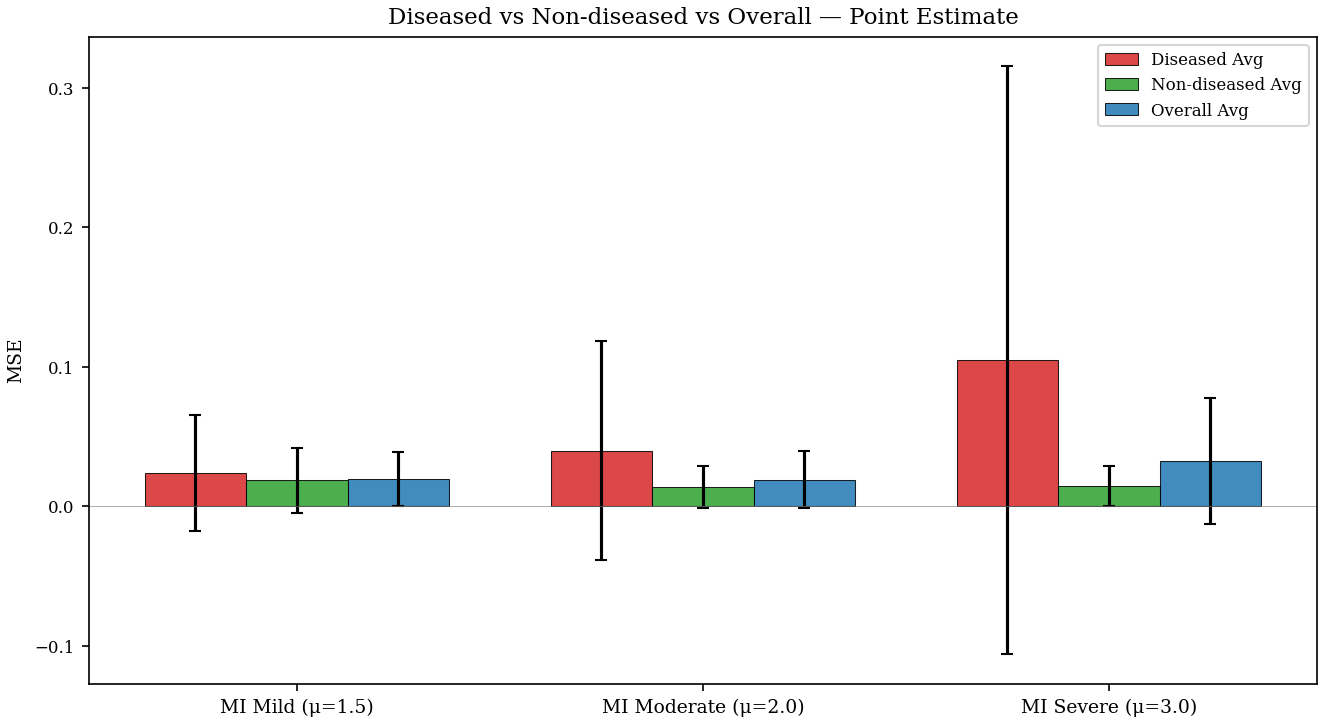

💾 Saved: LocalDisease\figures_error\bar_role_mcmc_crps.png


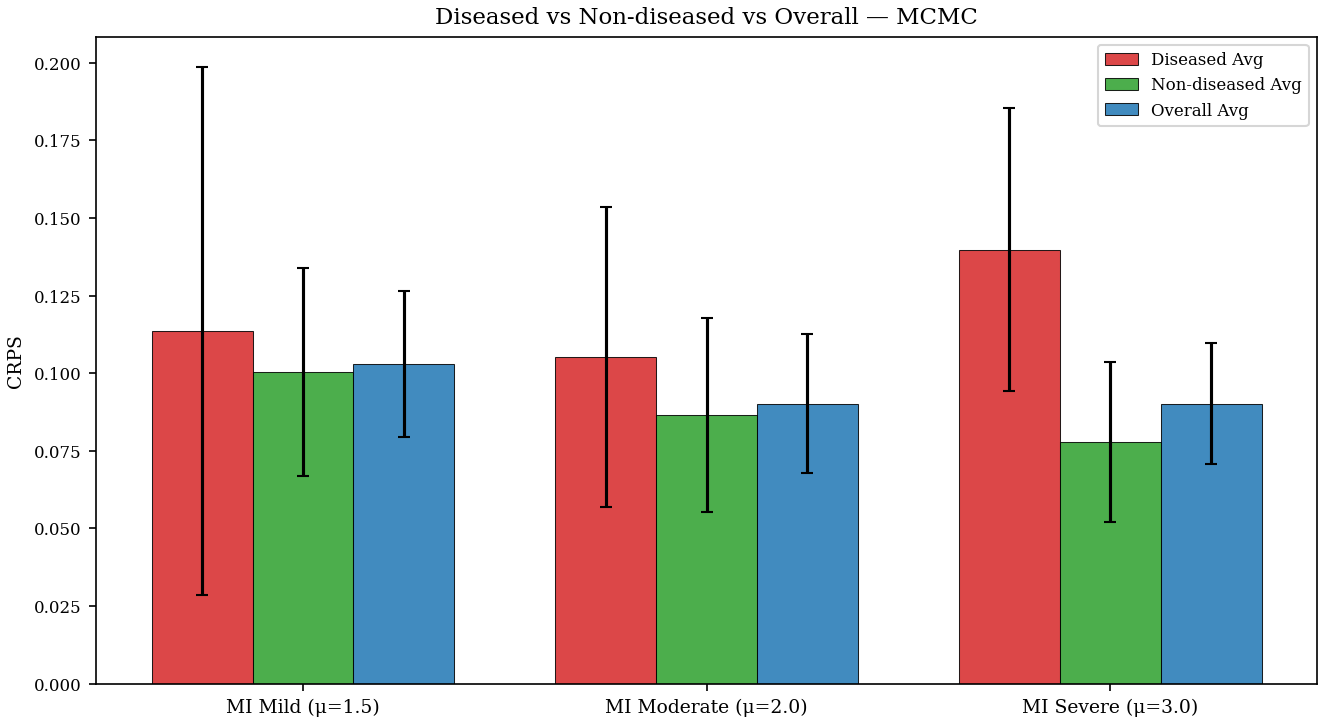

In [10]:
# ══════════════════════════════════════════════════════════════
# 4a. Diseased vs Non-diseased 柱状图（跨 severity）
# ══════════════════════════════════════════════════════════════

def plot_role_comparison_bars(df_agg, method, metric, ylabel, save_path=None):
    """
    柱状图: x = severity, grouped by aggregate_type (Diseased/Non-diseased/Overall).
    """
    df_plot = df_agg[
        (df_agg["method"] == method) &
        (df_agg["scenario"].isin(LOCAL_MI_SCENARIOS))
    ].copy()
    if len(df_plot) == 0:
        print(f"No data for {method}")
        return
    
    df_plot["Severity"] = df_plot["scenario"].map(SCENARIO_DISPLAY)
    
    # 计算每组的均值和标准差
    summary = df_plot.groupby(["Severity", "aggregate_type"])[metric].agg(["mean", "std"]).reset_index()
    
    fig, ax = plt.subplots(figsize=(9, 5))
    
    agg_types = ["Diseased Avg", "Non-diseased Avg", "Overall Avg"]
    agg_colors = {"Diseased Avg": "#d62728", "Non-diseased Avg": "#2ca02c", "Overall Avg": "#1f77b4"}
    severity_order = [SCENARIO_DISPLAY[s] for s in LOCAL_MI_SCENARIOS]
    
    x = np.arange(len(severity_order))
    n_groups = len(agg_types)
    width = 0.25
    
    for g_idx, atype in enumerate(agg_types):
        df_g = summary[summary["aggregate_type"] == atype]
        means = [df_g[df_g["Severity"] == sev]["mean"].values[0] 
                 if len(df_g[df_g["Severity"] == sev]) > 0 else 0 for sev in severity_order]
        stds = [df_g[df_g["Severity"] == sev]["std"].values[0]
                if len(df_g[df_g["Severity"] == sev]) > 0 else 0 for sev in severity_order]
        
        offset = (g_idx - n_groups / 2 + 0.5) * width
        bars = ax.bar(x + offset, means, width, yerr=stds, capsize=3,
                       label=atype, color=agg_colors[atype],
                       edgecolor="black", linewidth=0.5, alpha=0.85)
    
    ax.set_xticks(x)
    ax.set_xticklabels(severity_order, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Diseased vs Non-diseased vs Overall — {method}", fontsize=11)
    ax.legend(fontsize=8)
    ax.axhline(0, color="grey", linewidth=0.3)
    
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
        print(f"💾 Saved: {save_path}")
    plt.show()

# PE — MSE
plot_role_comparison_bars(df_agg, "Point Estimate", "mse", "MSE",
    save_path=Path(OUTPUT_DIR) / "bar_role_pe_mse.png")

# MCMC — CRPS
plot_role_comparison_bars(df_agg, "MCMC", "crps", "CRPS",
    save_path=Path(OUTPUT_DIR) / "bar_role_mcmc_crps.png")

### 4b. 逐 severity 的 Diseased / Non-diseased 箱线图

用箱线图展示每个 severity 下 Diseased 和 Non-diseased 的分布差异，揭示异质性和离群值。

💾 Saved: LocalDisease\figures_error\boxplot_role_point_estimate_mse.png


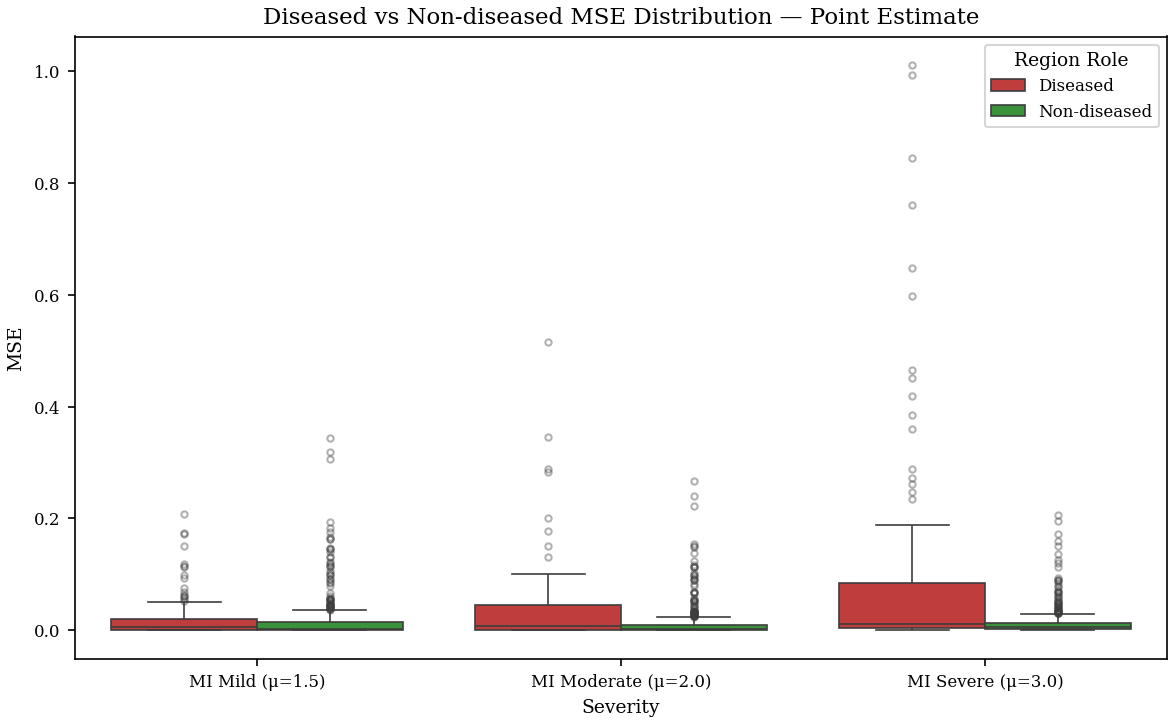

💾 Saved: LocalDisease\figures_error\boxplot_role_mcmc_crps.png


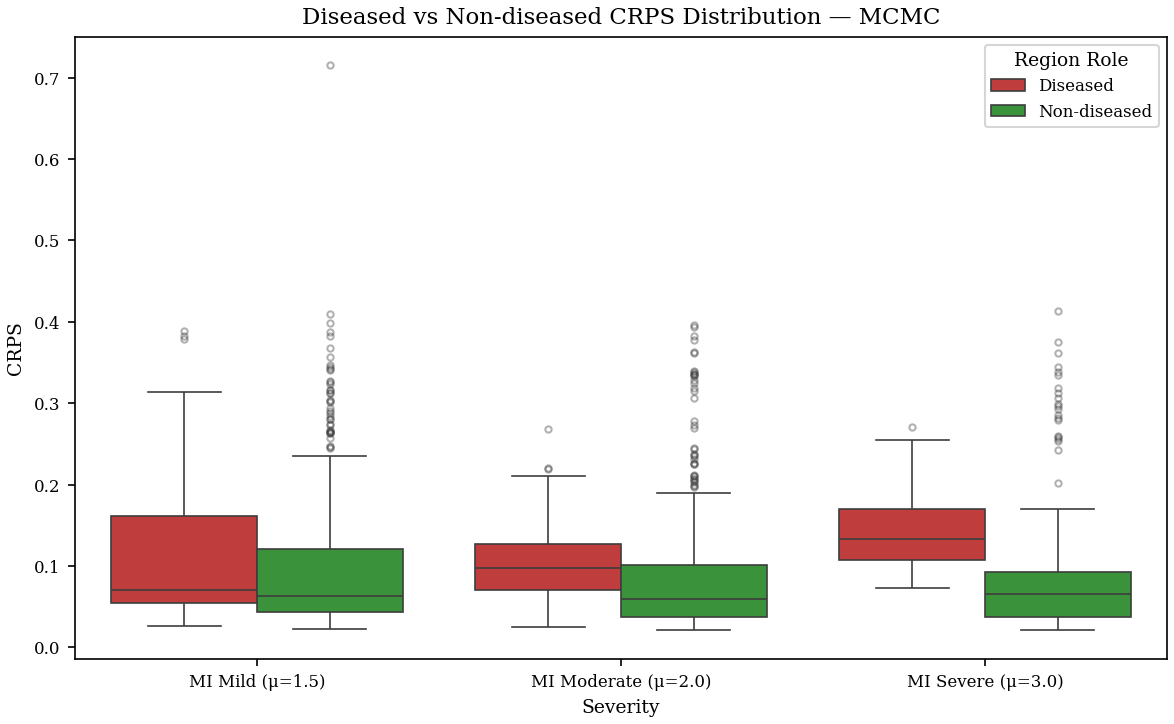

In [11]:
# ══════════════════════════════════════════════════════════════
# 4b. 箱线图: 按 severity + role 分组
# ══════════════════════════════════════════════════════════════

for method, metric, ylabel in [("Point Estimate", "mse", "MSE"), ("MCMC", "crps", "CRPS")]:
    df_mi = df_errors[
        (df_errors["scenario"].isin(LOCAL_MI_SCENARIOS)) &
        (df_errors["method"] == method) &
        (df_errors["region_role"].isin(["Diseased", "Non-diseased"]))
    ].copy()
    
    if len(df_mi) == 0:
        continue
    
    df_mi["Severity"] = df_mi["scenario"].map(SCENARIO_DISPLAY)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(
        data=df_mi, x="Severity", y=metric, hue="region_role",
        order=[SCENARIO_DISPLAY[s] for s in LOCAL_MI_SCENARIOS],
        hue_order=["Diseased", "Non-diseased"],
        palette={"Diseased": "#d62728", "Non-diseased": "#2ca02c"},
        ax=ax, flierprops=dict(marker="o", markersize=3, alpha=0.4),
        linewidth=0.8,
    )
    
    ax.set_ylabel(ylabel)
    ax.set_title(f"Diseased vs Non-diseased {ylabel} Distribution — {method}", fontsize=11)
    ax.legend(title="Region Role", fontsize=8)
    
    plt.tight_layout()
    save_path = Path(OUTPUT_DIR) / f"boxplot_role_{method.replace(' ','_').lower()}_{metric}.png"
    fig.savefig(save_path)
    print(f"💾 Saved: {save_path}")
    plt.show()

### 4c. Diseased / Non-diseased 误差比值

定义误差比值 $R = \frac{\text{Diseased Error}}{\text{Non-diseased Error}}$：

- $R > 1$: 病变区域误差 > 非病变区域 → 正常的误差集中模式
- $R \approx 1$: 两者相近 → equifinality 导致误差"扩散"
- $R < 1$: 非病变区域误差反而更高 → 严重的补偿效应/定位失败

跟踪这个比值随 severity 的变化，揭示 equifinality 的演变。

In [12]:
# ══════════════════════════════════════════════════════════════
# 4c. 误差比值 R = Diseased / Non-diseased
# ══════════════════════════════════════════════════════════════

ratio_records = []

for method, metric in [("Point Estimate", "mse"), ("MCMC", "crps")]:
    df_agg_method = df_agg[
        (df_agg["method"] == method) &
        (df_agg["scenario"].isin(LOCAL_MI_SCENARIOS))
    ]
    
    for scenario in LOCAL_MI_SCENARIOS:
        df_sc = df_agg_method[df_agg_method["scenario"] == scenario]
        
        for sample_idx in range(N_SAMPLES):
            df_s = df_sc[df_sc["sample_idx"] == sample_idx]
            
            d_row = df_s[df_s["aggregate_type"] == "Diseased Avg"]
            nd_row = df_s[df_s["aggregate_type"] == "Non-diseased Avg"]
            
            if len(d_row) > 0 and len(nd_row) > 0:
                d_val = d_row[metric].values[0]
                nd_val = nd_row[metric].values[0]
                ratio = d_val / (nd_val + 1e-12)
                
                ratio_records.append({
                    "scenario": scenario,
                    "scenario_display": SCENARIO_DISPLAY[scenario],
                    "sample_idx": sample_idx,
                    "method": method,
                    "metric": metric,
                    "diseased_val": d_val,
                    "non_diseased_val": nd_val,
                    "ratio": ratio,
                })

df_ratio = pd.DataFrame(ratio_records)

# 按 severity 展示统计
print("Error Ratio R = Diseased / Non-diseased")
print("=" * 70)
for method, metric in [("Point Estimate", "mse"), ("MCMC", "crps")]:
    print(f"\n  {method} ({metric.upper()}):")
    df_m = df_ratio[df_ratio["method"] == method]
    for scenario in LOCAL_MI_SCENARIOS:
        df_s = df_m[df_m["scenario"] == scenario]
        if len(df_s) > 0:
            r_med = df_s["ratio"].median()
            r_mean = df_s["ratio"].mean()
            pct_gt1 = (df_s["ratio"] > 1).mean() * 100
            print(f"    {SCENARIO_DISPLAY[scenario]:<25} "
                  f"median R = {r_med:.2f}, mean R = {r_mean:.2f}, "
                  f"R>1 in {pct_gt1:.0f}% of samples")

df_ratio.to_csv(Path(CSV_DIR) / "diseased_nondiseased_ratio.csv", index=False, float_format="%.6f")
print(f"\n✅ Saved: {CSV_DIR}/diseased_nondiseased_ratio.csv")

Error Ratio R = Diseased / Non-diseased

  Point Estimate (MSE):
    MI Mild (μ=1.5)           median R = 0.50, mean R = 4.28, R>1 in 35% of samples
    MI Moderate (μ=2.0)       median R = 0.85, mean R = 9.00, R>1 in 48% of samples
    MI Severe (μ=3.0)         median R = 1.11, mean R = 8.33, R>1 in 53% of samples

  MCMC (CRPS):
    MI Mild (μ=1.5)           median R = 0.75, mean R = 1.41, R>1 in 38% of samples
    MI Moderate (μ=2.0)       median R = 0.99, mean R = 1.46, R>1 in 49% of samples
    MI Severe (μ=3.0)         median R = 1.60, mean R = 2.06, R>1 in 89% of samples

✅ Saved: LocalDisease/csv_results/diseased_nondiseased_ratio.csv


C:\Users\r4718\AppData\Local\Temp\ipykernel_20928\1863270738.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


💾 Saved: LocalDisease\figures_error\boxplot_ratio_point_estimate.png


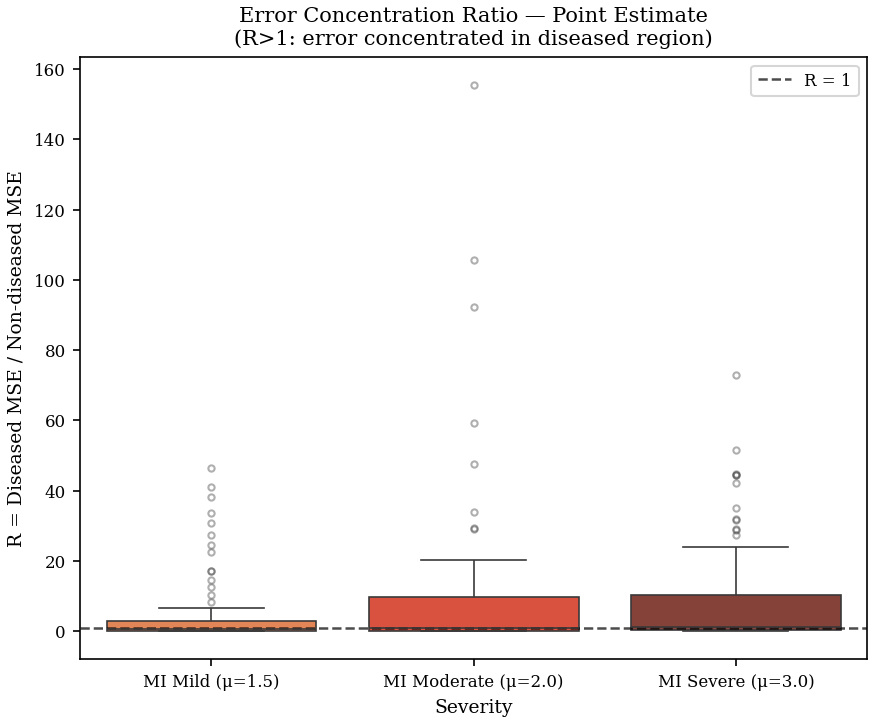

C:\Users\r4718\AppData\Local\Temp\ipykernel_20928\1863270738.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


💾 Saved: LocalDisease\figures_error\boxplot_ratio_mcmc.png


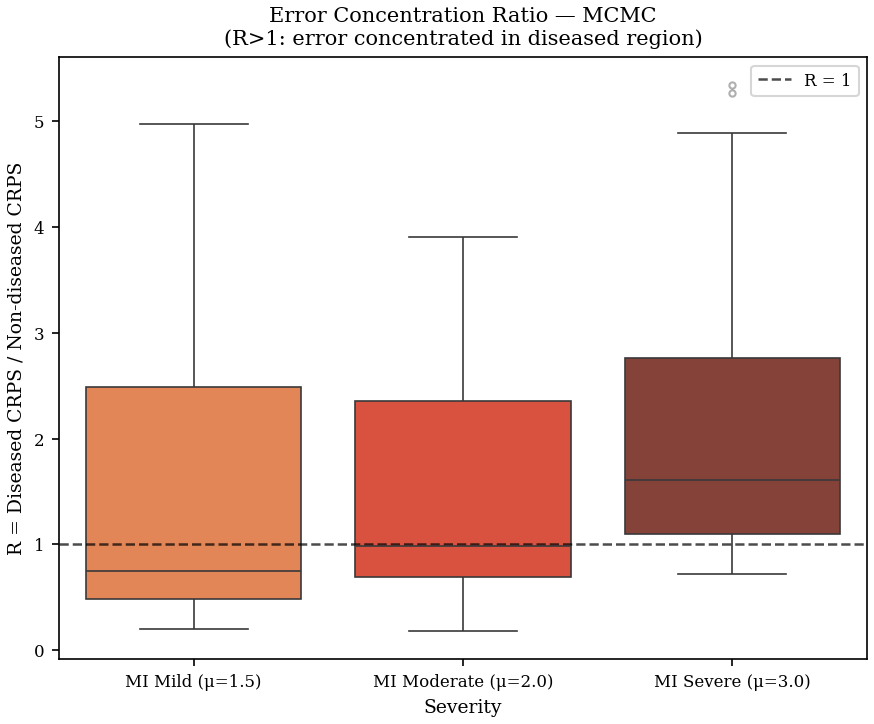

In [13]:
# ── 比值 R 的箱线图 ──
for method, metric_label in [("Point Estimate", "MSE"), ("MCMC", "CRPS")]:
    df_m = df_ratio[df_ratio["method"] == method].copy()
    if len(df_m) == 0:
        continue
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    palette = sns.color_palette("YlOrRd_d", 3)
    severity_order = [SCENARIO_DISPLAY[s] for s in LOCAL_MI_SCENARIOS]
    
    sns.boxplot(
        data=df_m, x="scenario_display", y="ratio",
        order=severity_order, palette=palette, ax=ax,
        flierprops=dict(marker="o", markersize=3, alpha=0.4),
        linewidth=0.8,
    )
    
    ax.axhline(1.0, color="black", linewidth=1.2, linestyle="--", alpha=0.7, label="R = 1")
    ax.set_xlabel("Severity")
    ax.set_ylabel(f"R = Diseased {metric_label} / Non-diseased {metric_label}")
    ax.set_title(f"Error Concentration Ratio — {method}\n(R>1: error concentrated in diseased region)",
                 fontsize=10)
    ax.legend(fontsize=8)
    
    plt.tight_layout()
    save_path = Path(OUTPUT_DIR) / f"boxplot_ratio_{method.replace(' ','_').lower()}.png"
    fig.savefig(save_path)
    print(f"💾 Saved: {save_path}")
    plt.show()

### 4d. 逐区域的 Diseased vs Non-diseased 细分

进一步按**具体哪个区域病变**来拆分，观察：
- 不同区域病变时，非病变区域的误差水平是否一致？
- 某些区域病变是否导致更严重的"溢出"效应？

💾 Saved: LocalDisease\figures_error\facet_role_MI_1_point_estimate.png


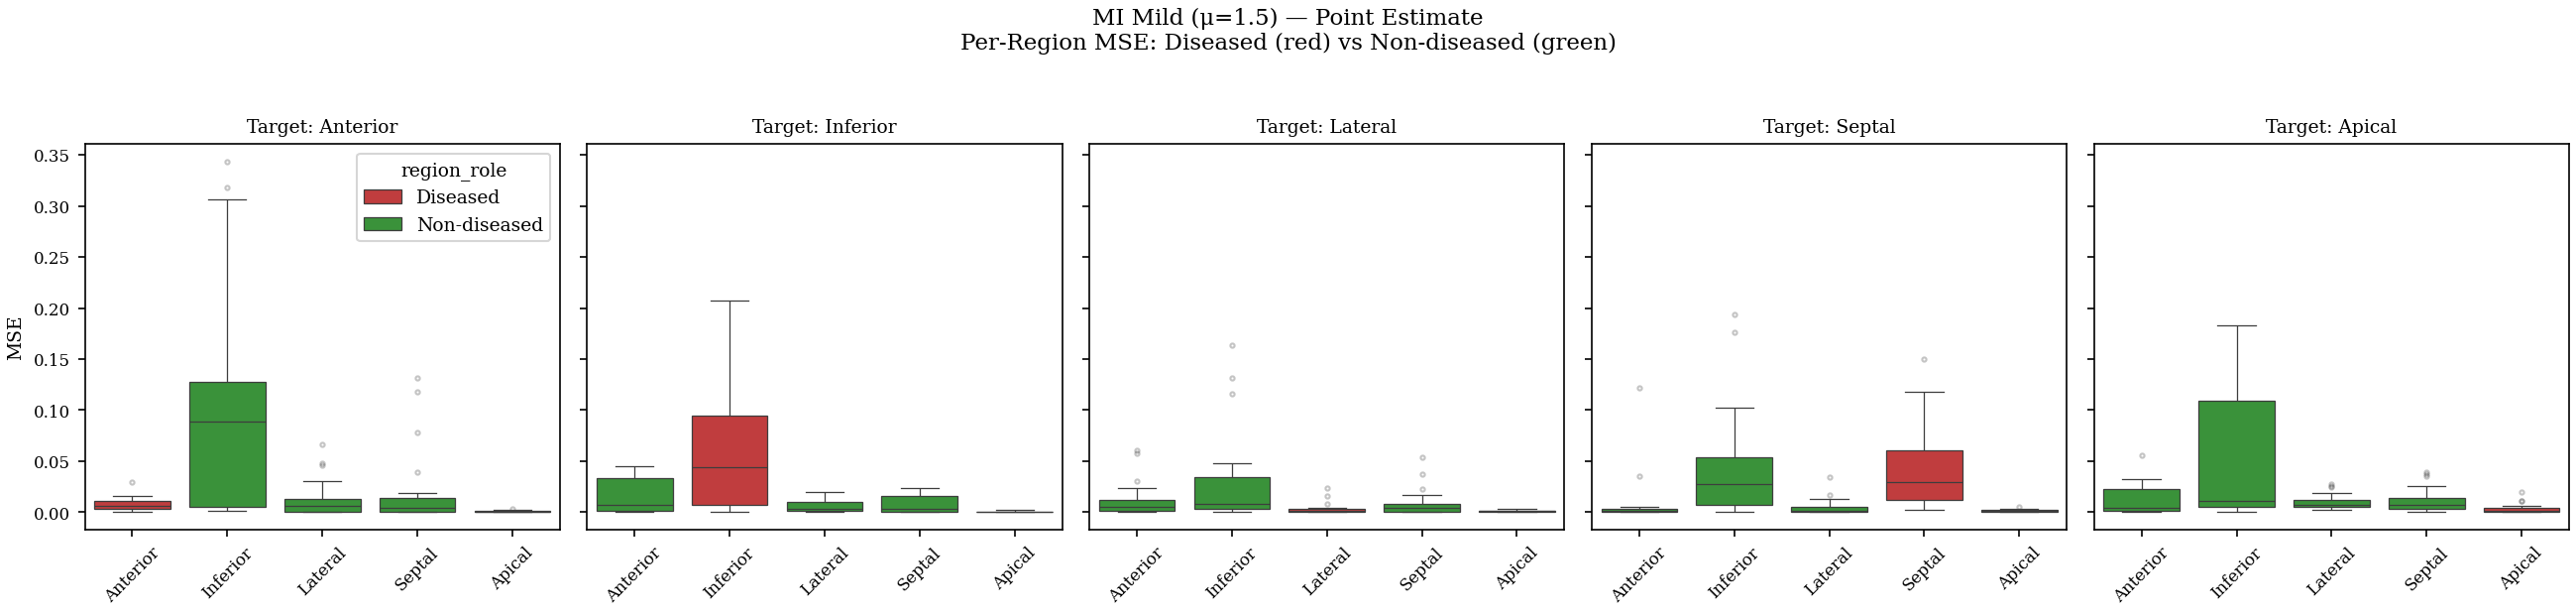

💾 Saved: LocalDisease\figures_error\facet_role_MI_2_point_estimate.png


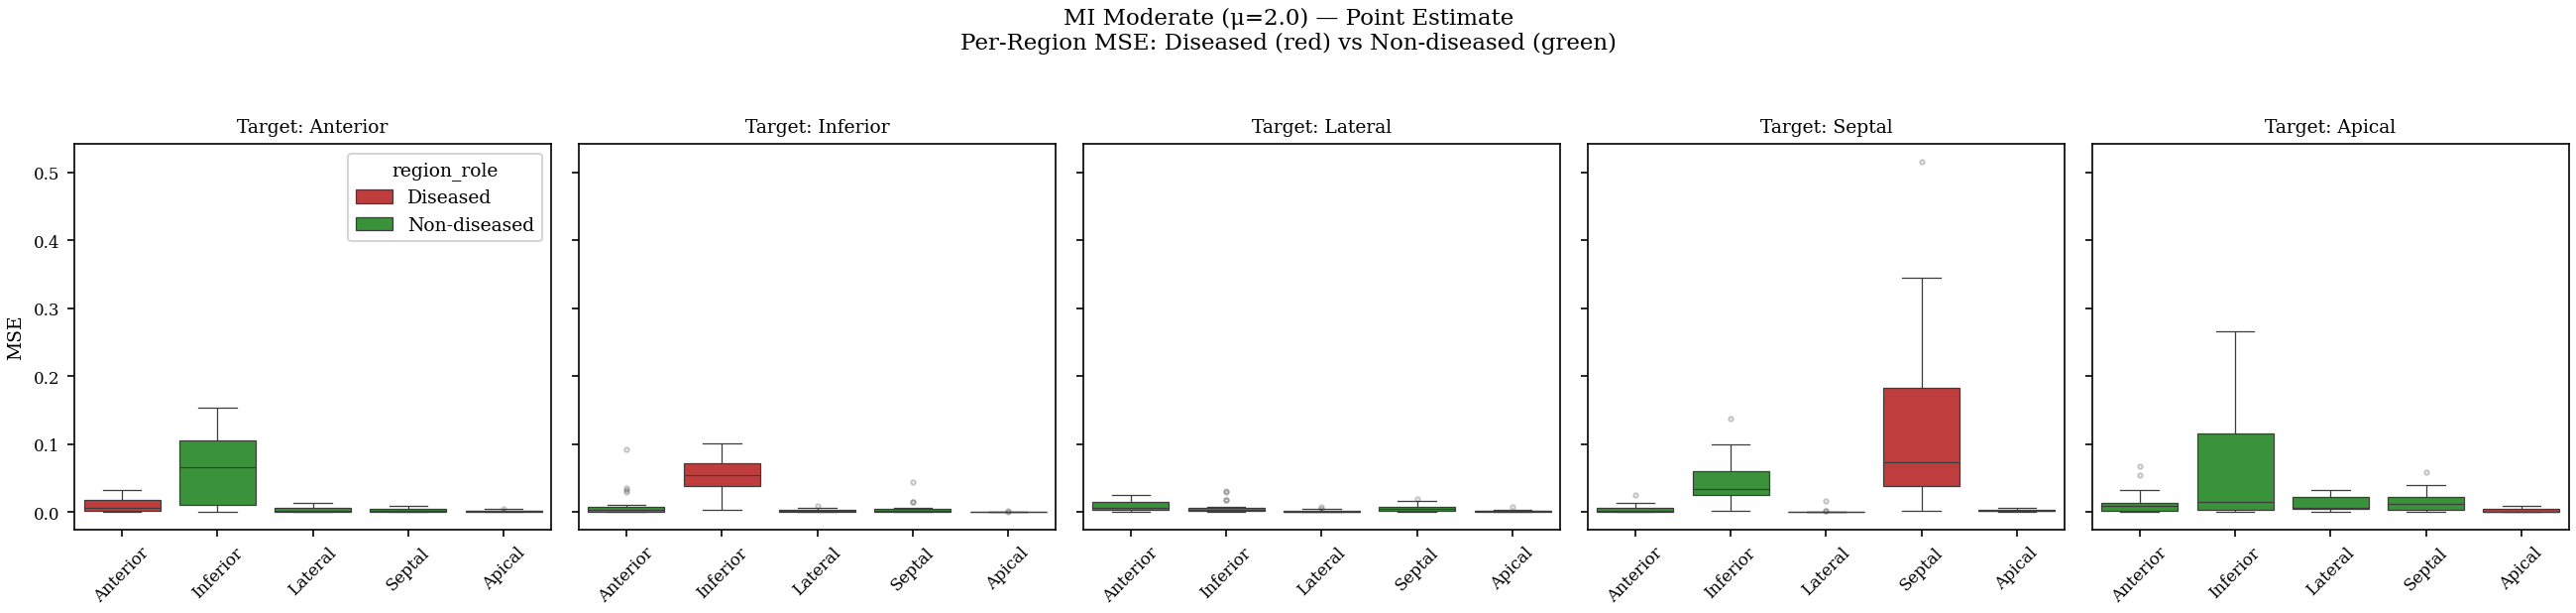

💾 Saved: LocalDisease\figures_error\facet_role_MI_3_point_estimate.png


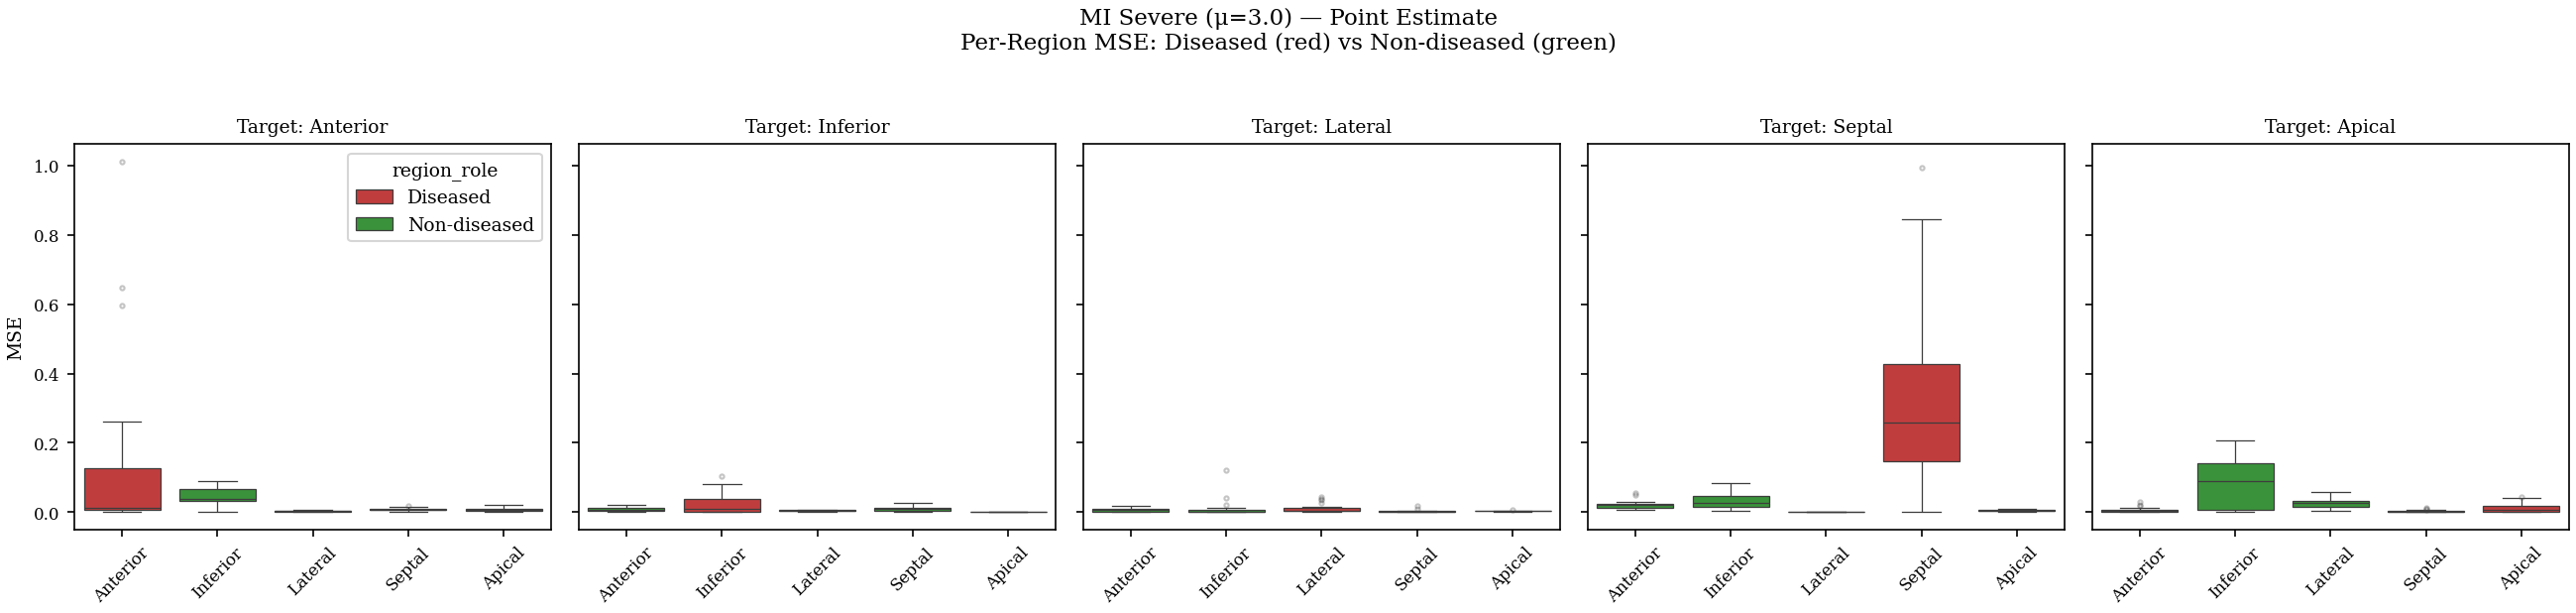

💾 Saved: LocalDisease\figures_error\facet_role_MI_1_mcmc.png


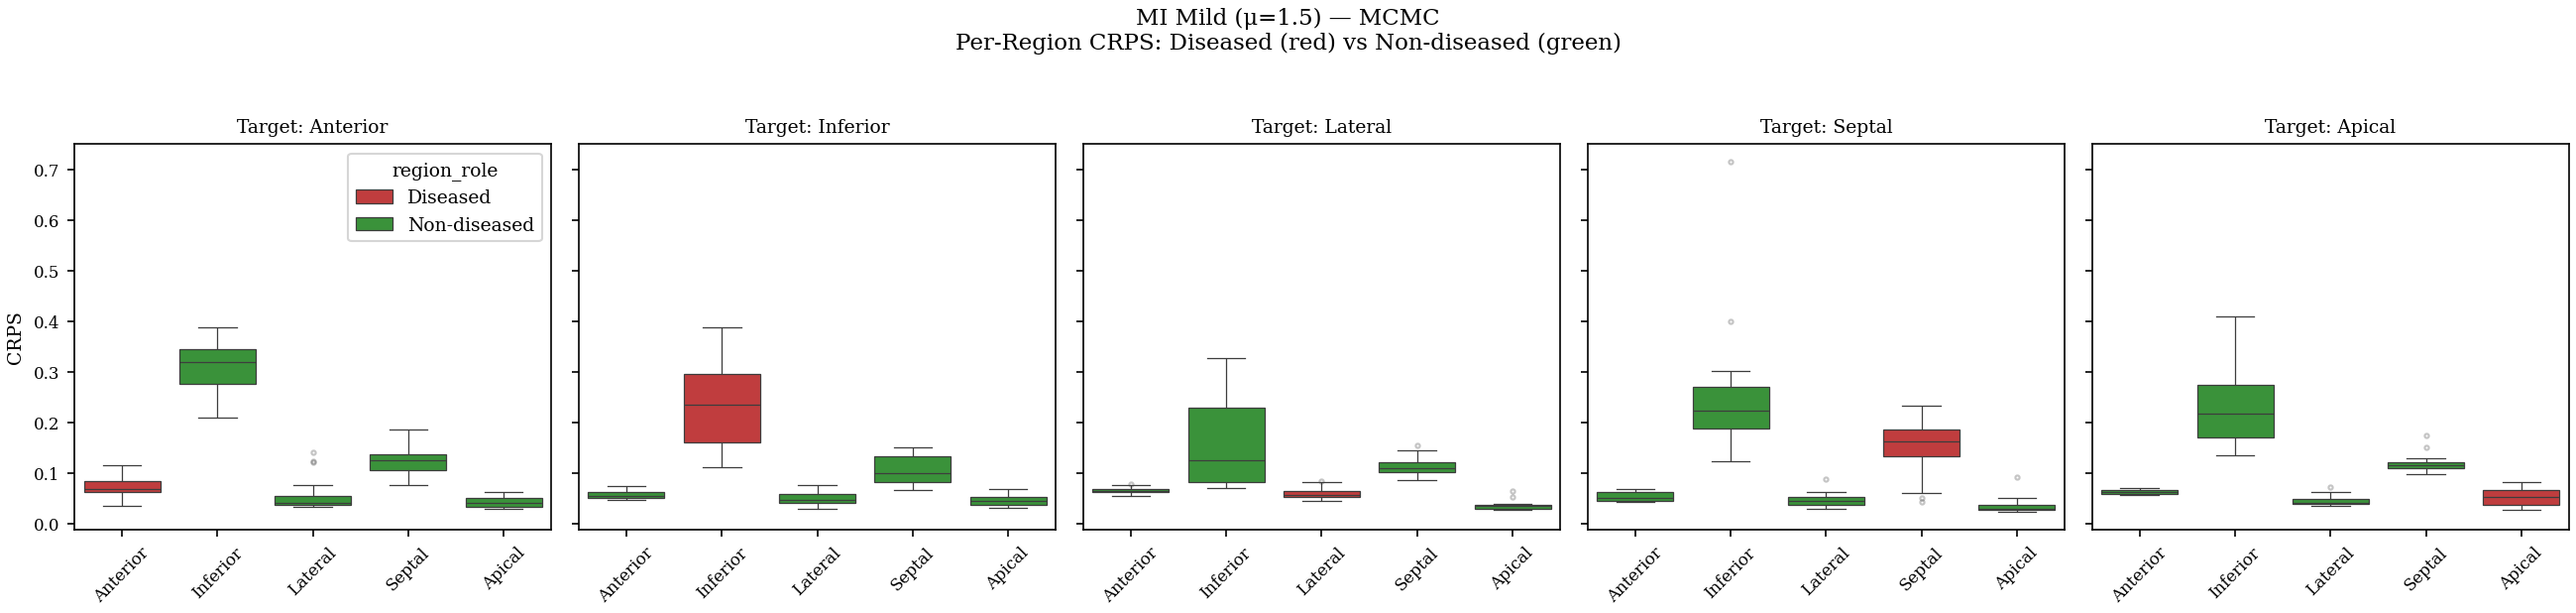

💾 Saved: LocalDisease\figures_error\facet_role_MI_2_mcmc.png


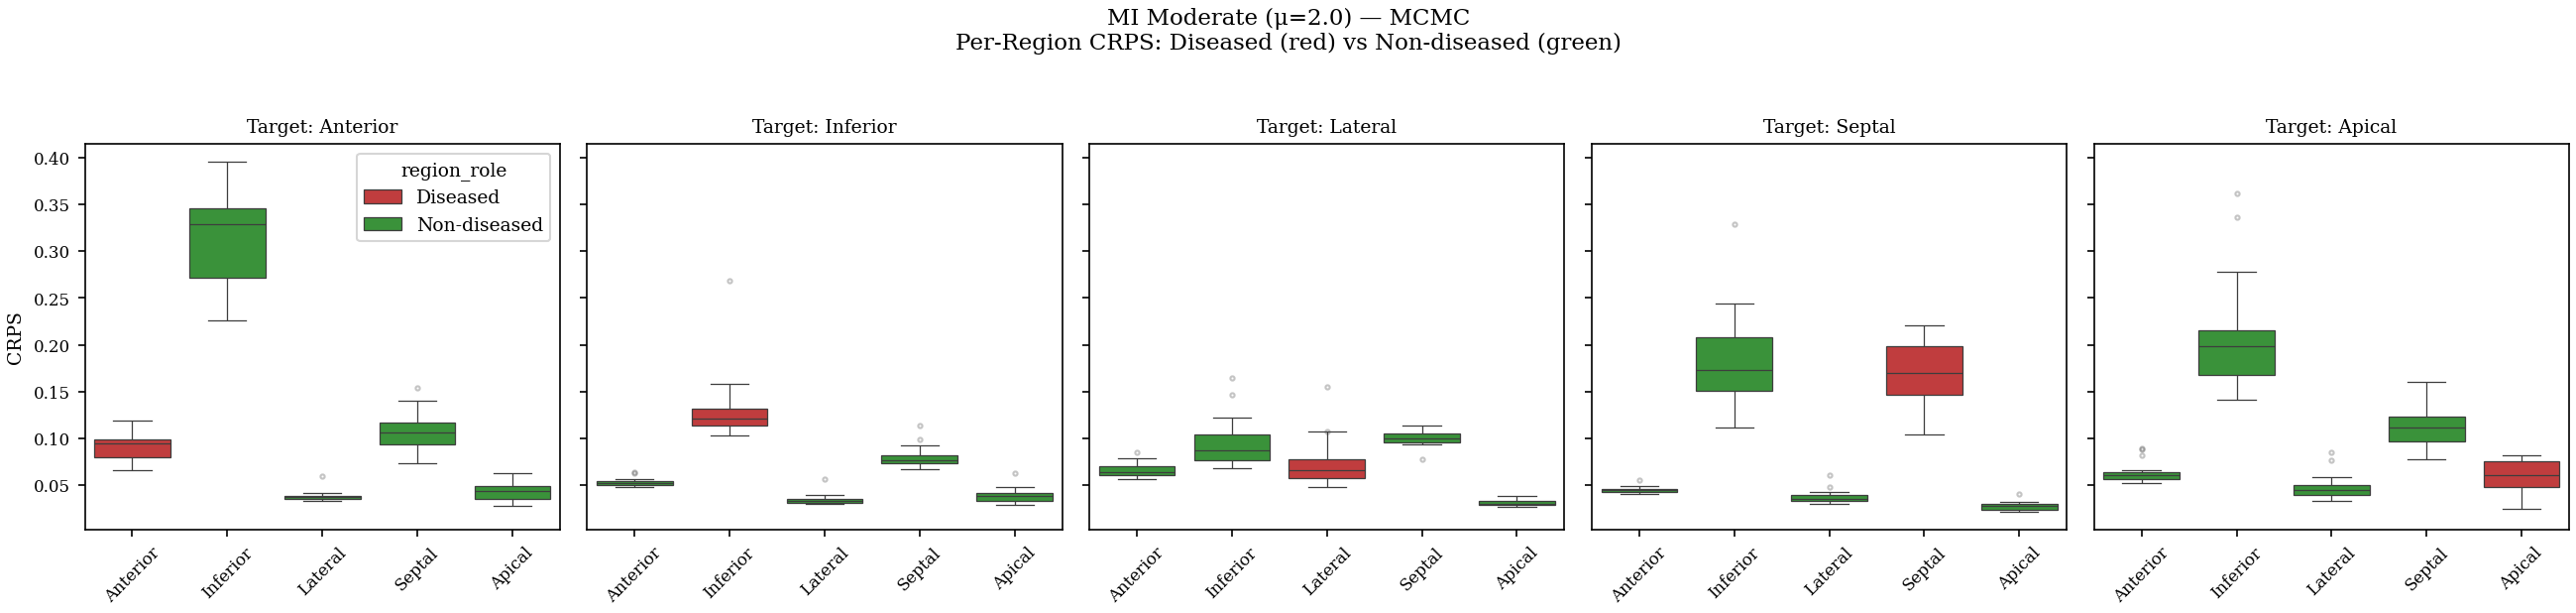

💾 Saved: LocalDisease\figures_error\facet_role_MI_3_mcmc.png


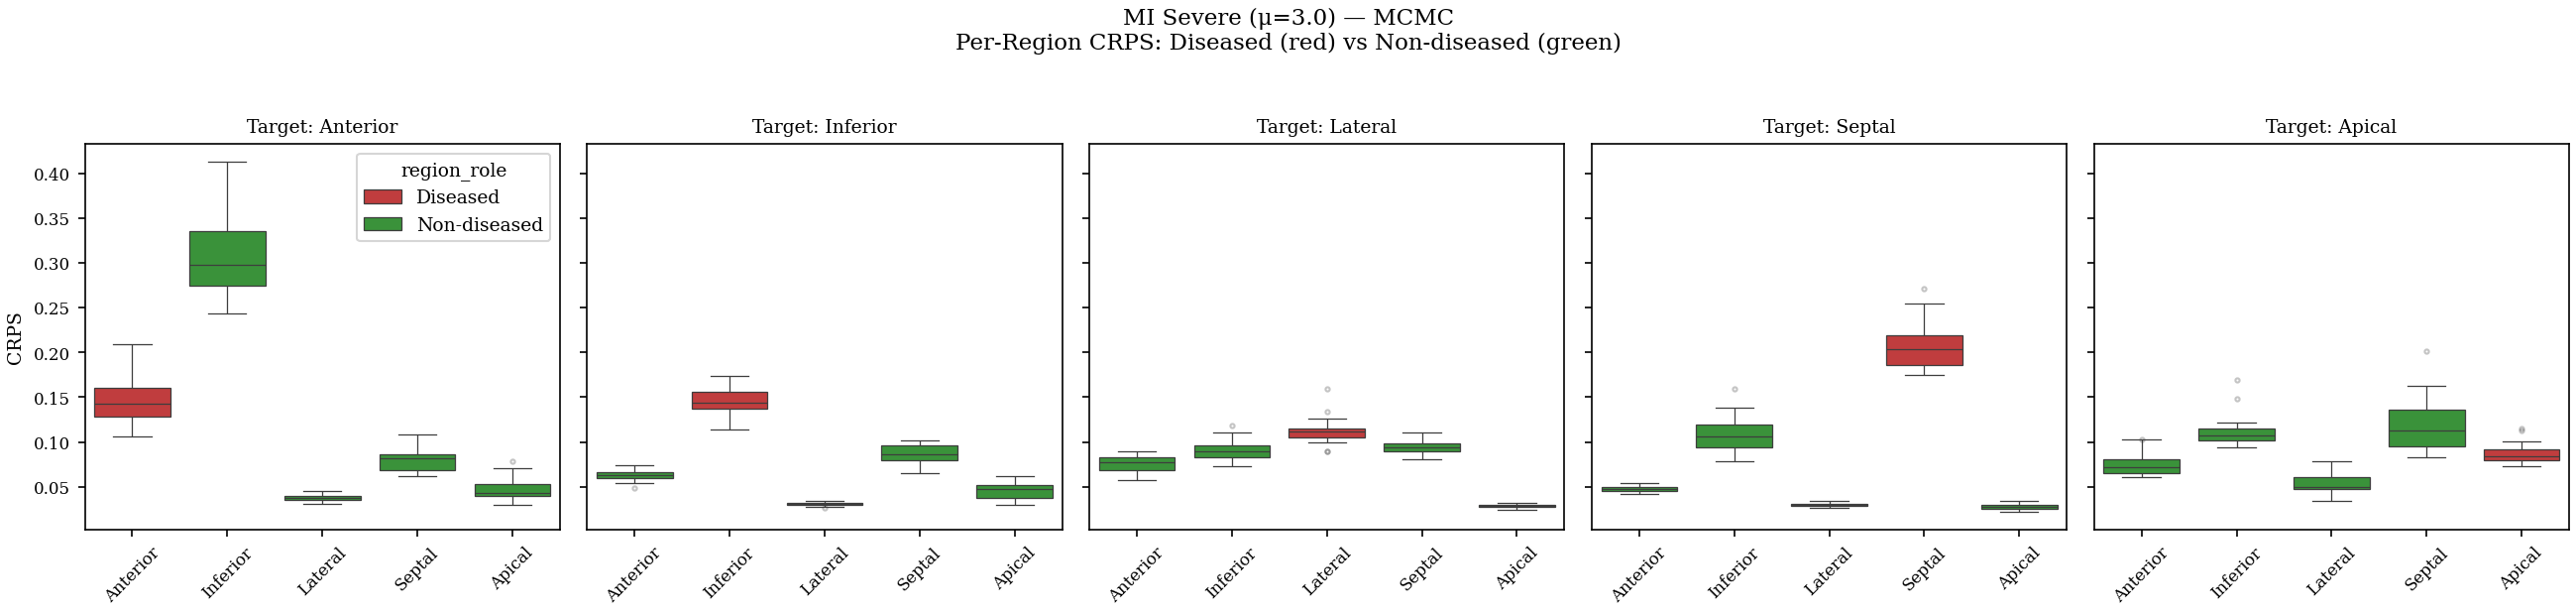

In [14]:
# ══════════════════════════════════════════════════════════════
# 4d. 按 target region 分面: Diseased vs Non-diseased
# ══════════════════════════════════════════════════════════════

for method, metric, ylabel in [("Point Estimate", "mse", "MSE"), ("MCMC", "crps", "CRPS")]:
    for scenario in LOCAL_MI_SCENARIOS:
        df_sc = df_errors[
            (df_errors["scenario"] == scenario) &
            (df_errors["method"] == method) &
            (df_errors["region_role"].isin(["Diseased", "Non-diseased"]))
        ].copy()
        
        if len(df_sc) == 0:
            continue
        
        fig, axes = plt.subplots(1, N_REGIONS, figsize=(3.5 * N_REGIONS, 4), sharey=True)
        
        for t_idx in range(N_REGIONS):
            ax = axes[t_idx]
            df_t = df_sc[df_sc["target_region_idx"] == t_idx]
            
            if len(df_t) == 0:
                ax.set_title(f"Target: {REGION_LABELS[t_idx]}")
                continue
            
            sns.boxplot(
                data=df_t, x="inferred_region", y=metric,
                order=REGION_LABELS, ax=ax,
                hue="region_role", hue_order=["Diseased", "Non-diseased"],
                palette={"Diseased": "#d62728", "Non-diseased": "#2ca02c"},
                flierprops=dict(marker="o", markersize=2, alpha=0.3),
                linewidth=0.6,
            )
            
            ax.set_title(f"Target: {REGION_LABELS[t_idx]}", fontsize=9)
            ax.set_xlabel("")
            if t_idx == 0:
                ax.set_ylabel(ylabel)
            else:
                ax.set_ylabel("")
                ax.get_legend().remove() if ax.get_legend() else None
            ax.tick_params(axis="x", rotation=45)
        
        # 只保留第一个子图的 legend
        for a_idx in range(1, N_REGIONS):
            leg = axes[a_idx].get_legend()
            if leg:
                leg.remove()
        
        fig.suptitle(f"{SCENARIO_DISPLAY[scenario]} — {method}\n"
                     f"Per-Region {ylabel}: Diseased (red) vs Non-diseased (green)",
                     fontsize=11, y=1.04)
        plt.tight_layout()
        save_path = Path(OUTPUT_DIR) / f"facet_role_{scenario}_{method.replace(' ','_').lower()}.png"
        fig.savefig(save_path, bbox_inches="tight")
        print(f"💾 Saved: {save_path}")
        plt.show()

### 4e. 全局误差趋势: Overall Avg 随 severity 的变化

跟踪 10 个参数的整体推断质量如何随病变严重程度变化。  
如果 equifinality 随 severity 加剧，Overall Avg 可能反而**不会**显著恶化（因为补偿效应使得全局力学响应仍可匹配），但 Diseased 和 Non-diseased 的分布会更加扁平（均匀分散）。

💾 Saved: LocalDisease\figures_error\trend_role_point_estimate.png


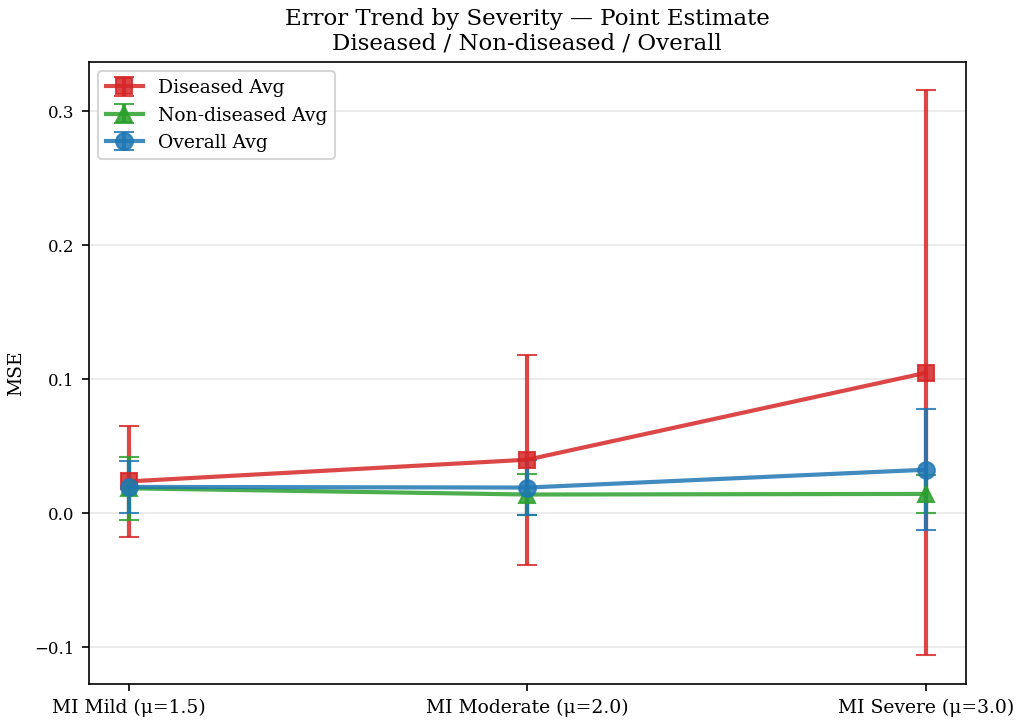

💾 Saved: LocalDisease\figures_error\trend_role_mcmc.png


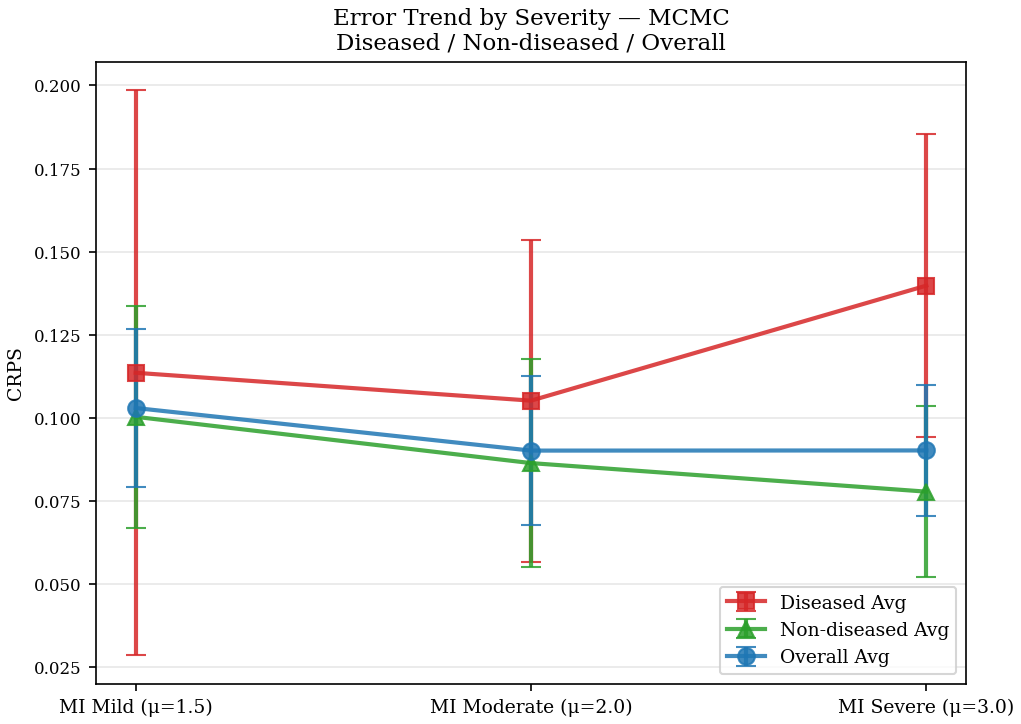

In [15]:
# ══════════════════════════════════════════════════════════════
# 4e. 三线趋势图: Diseased / Non-diseased / Overall 随 severity 变化
# ══════════════════════════════════════════════════════════════

for method, metric, ylabel in [("Point Estimate", "mse", "MSE"), ("MCMC", "crps", "CRPS")]:
    df_agg_method = df_agg[
        (df_agg["method"] == method) &
        (df_agg["scenario"].isin(LOCAL_MI_SCENARIOS))
    ].copy()
    
    if len(df_agg_method) == 0:
        continue
    
    fig, ax = plt.subplots(figsize=(7, 5))
    
    agg_types = ["Diseased Avg", "Non-diseased Avg", "Overall Avg"]
    colors = {"Diseased Avg": "#d62728", "Non-diseased Avg": "#2ca02c", "Overall Avg": "#1f77b4"}
    markers = {"Diseased Avg": "s", "Non-diseased Avg": "^", "Overall Avg": "o"}
    
    x_positions = np.arange(len(LOCAL_MI_SCENARIOS))
    x_labels = [SCENARIO_DISPLAY[s] for s in LOCAL_MI_SCENARIOS]
    
    for atype in agg_types:
        means, stds = [], []
        for scenario in LOCAL_MI_SCENARIOS:
            df_g = df_agg_method[
                (df_agg_method["scenario"] == scenario) &
                (df_agg_method["aggregate_type"] == atype)
            ]
            if len(df_g) > 0:
                means.append(df_g[metric].mean())
                stds.append(df_g[metric].std())
            else:
                means.append(np.nan)
                stds.append(np.nan)
        
        ax.errorbar(x_positions, means, yerr=stds, marker=markers[atype],
                     color=colors[atype], linewidth=2, markersize=8,
                     capsize=5, label=atype, alpha=0.85)
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Error Trend by Severity — {method}\n"
                 f"Diseased / Non-diseased / Overall", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    save_path = Path(OUTPUT_DIR) / f"trend_role_{method.replace(' ','_').lower()}.png"
    fig.savefig(save_path)
    print(f"💾 Saved: {save_path}")
    plt.show()

### 4f. MCMC 特有: 按 region role 的 Calibration 和 Sharpness

非病变区域的后验 calibration 是否与病变区域不同？  
如果 equifinality 导致补偿效应，非病变区域的后验可能**过度自信**（CI 窄但不覆盖真值）。

💾 Saved: LocalDisease/figures_error/reliability_by_role.png


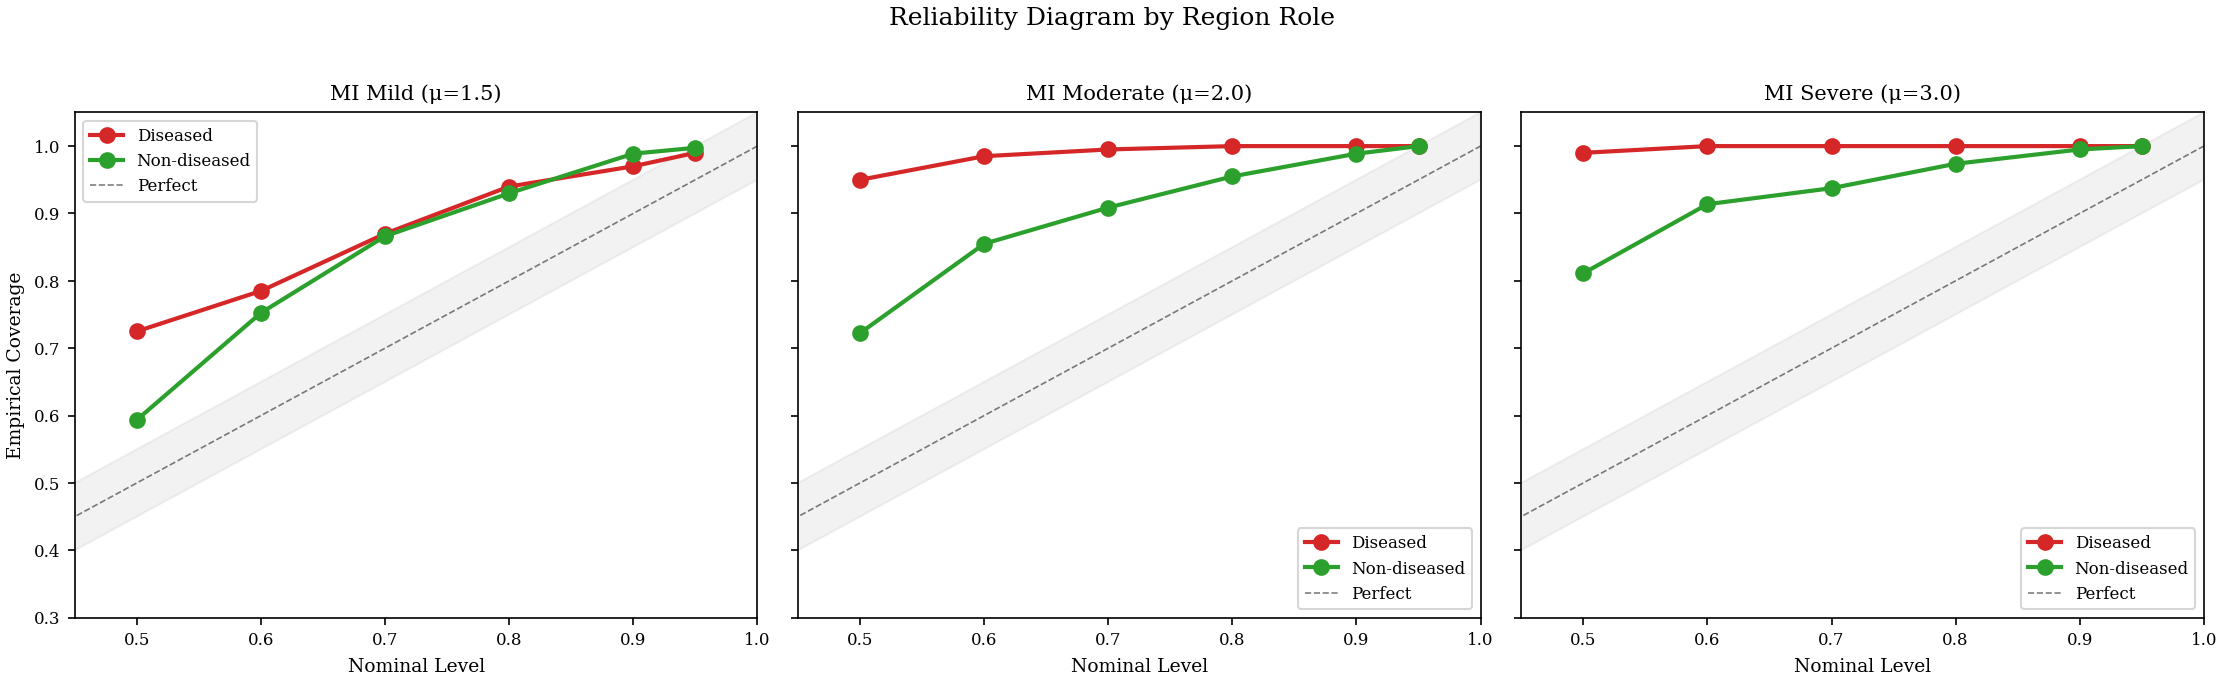

In [16]:
# ══════════════════════════════════════════════════════════════
# 4f. 按 region_role 的 Calibration 和 CI Width
# ══════════════════════════════════════════════════════════════

# ── Calibration by role ──
fig, axes = plt.subplots(1, len(LOCAL_MI_SCENARIOS), figsize=(5 * len(LOCAL_MI_SCENARIOS), 4.5),
                          sharey=True)
if len(LOCAL_MI_SCENARIOS) == 1:
    axes = [axes]

role_colors = {"Diseased": "#d62728", "Non-diseased": "#2ca02c"}

for ax_idx, scenario in enumerate(LOCAL_MI_SCENARIOS):
    ax = axes[ax_idx]
    df_sc = df_calib[df_calib["scenario"] == scenario]
    
    for role in ["Diseased", "Non-diseased"]:
        df_role = df_sc[df_sc["region_role"] == role]
        if len(df_role) == 0:
            continue
        emp = df_role.groupby("credible_level")["covered"].mean()
        ax.plot(emp.index, emp.values, "o-", color=role_colors[role],
                linewidth=2, markersize=7, label=role)
    
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5, label="Perfect")
    ax.fill_between([0, 1], [-0.05, 0.95], [0.05, 1.05], alpha=0.1, color="grey")
    ax.set_title(SCENARIO_DISPLAY[scenario], fontsize=10)
    ax.set_xlabel("Nominal Level")
    if ax_idx == 0:
        ax.set_ylabel("Empirical Coverage")
    ax.set_xlim(0.45, 1.0)
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=8)

fig.suptitle("Reliability Diagram by Region Role", fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(Path(OUTPUT_DIR) / "reliability_by_role.png", bbox_inches="tight")
print(f"💾 Saved: {OUTPUT_DIR}/reliability_by_role.png")
plt.show()

💾 Saved: LocalDisease/figures_error/role_ciwidth_coverage.png


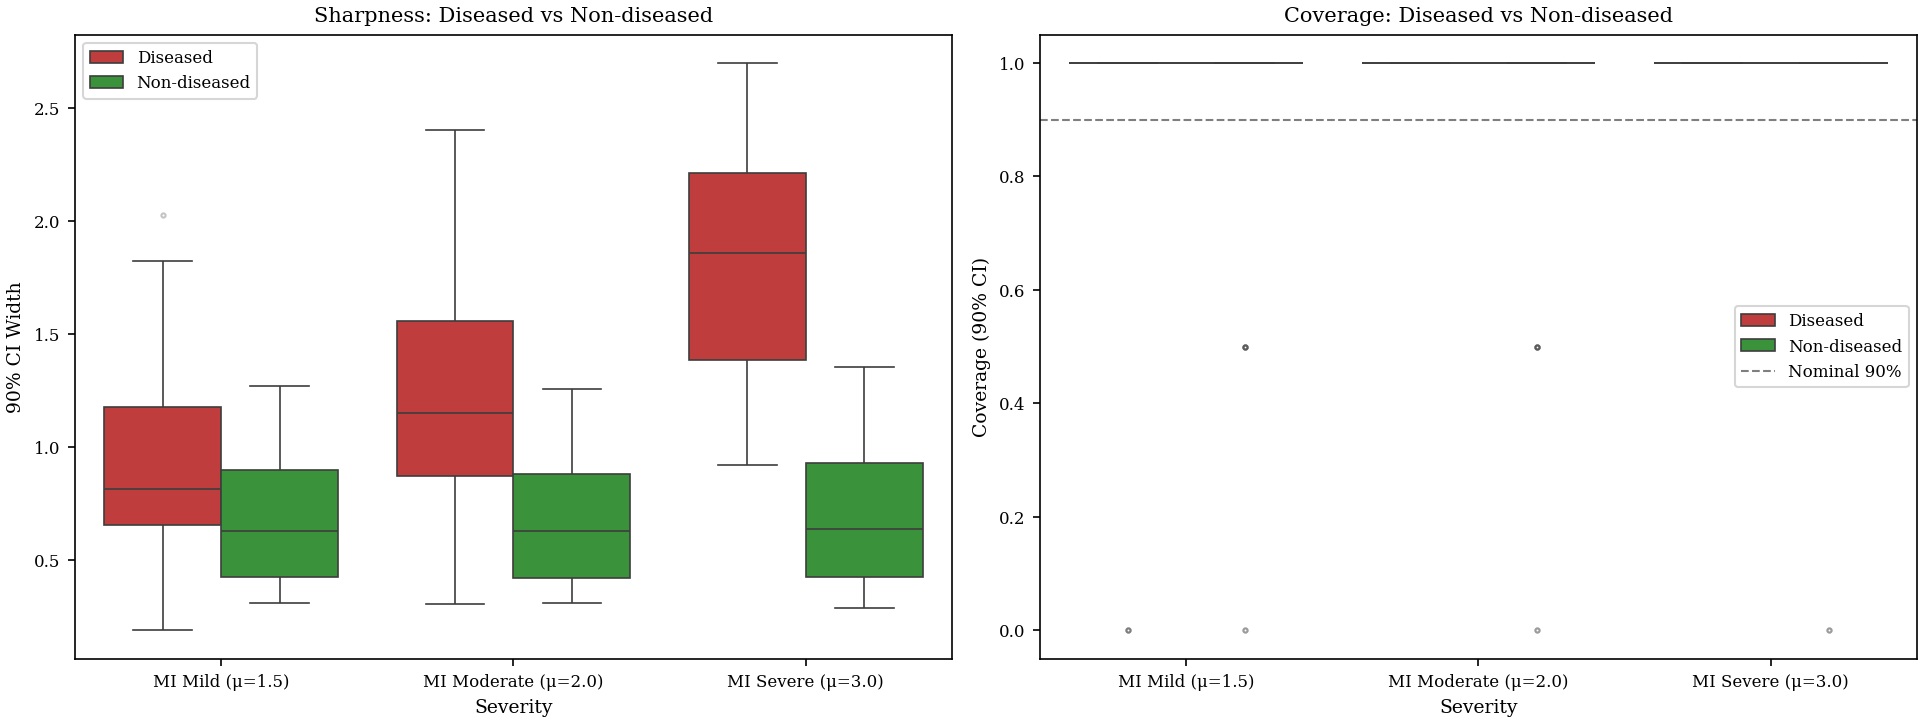

In [17]:
# ── CI Width by role ──
df_mc_mi = df_errors[
    (df_errors["method"] == "MCMC") &
    (df_errors["scenario"].isin(LOCAL_MI_SCENARIOS)) &
    (df_errors["region_role"].isin(["Diseased", "Non-diseased"]))
].copy()
df_mc_mi["Severity"] = df_mc_mi["scenario"].map(SCENARIO_DISPLAY)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CI Width
sns.boxplot(
    data=df_mc_mi, x="Severity", y="ci_width", hue="region_role",
    order=[SCENARIO_DISPLAY[s] for s in LOCAL_MI_SCENARIOS],
    hue_order=["Diseased", "Non-diseased"],
    palette=role_colors, ax=axes[0],
    flierprops=dict(marker="o", markersize=2, alpha=0.3), linewidth=0.8,
)
axes[0].set_ylabel("90% CI Width")
axes[0].set_title("Sharpness: Diseased vs Non-diseased", fontsize=10)
axes[0].legend(fontsize=8)

# Coverage
sns.boxplot(
    data=df_mc_mi, x="Severity", y="coverage", hue="region_role",
    order=[SCENARIO_DISPLAY[s] for s in LOCAL_MI_SCENARIOS],
    hue_order=["Diseased", "Non-diseased"],
    palette=role_colors, ax=axes[1],
    flierprops=dict(marker="o", markersize=2, alpha=0.3), linewidth=0.8,
)
axes[1].axhline(0.90, color="black", linewidth=1, linestyle="--", alpha=0.5, label="Nominal 90%")
axes[1].set_ylabel("Coverage (90% CI)")
axes[1].set_title("Coverage: Diseased vs Non-diseased", fontsize=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(Path(OUTPUT_DIR) / "role_ciwidth_coverage.png")
print(f"💾 Saved: {OUTPUT_DIR}/role_ciwidth_coverage.png")
plt.show()

---## 5. 交叉误差矩阵### 功能说明构建 5×5 交叉误差矩阵（仅限 MI 场景）。分别用两种指标：- **PE**: 矩阵元素 = MSE- **MCMC**: 矩阵元素 = **CRPS**（而非中位数 MSE）行 = 病变区域 (target), 列 = 推断区域 (inferred), 元素 = 20 个 sample 的均值。

In [18]:
def build_cross_error_matrix(df_errors, scenario, method, metric="crps"):
    """
    构建 5×5 交叉误差矩阵。
    metric: 'mse', 'crps', 'interval_score', 'ci_width'
    """
    df = df_errors[(df_errors["scenario"] == scenario) & (df_errors["method"] == method)]
    
    mean_mat = np.full((N_REGIONS, N_REGIONS), np.nan)
    std_mat = np.full((N_REGIONS, N_REGIONS), np.nan)
    
    for dr in range(N_REGIONS):
        for ir in range(N_REGIONS):
            vals = df[(df["target_region_idx"] == dr) & (df["inferred_region_idx"] == ir)][metric].dropna()
            if len(vals) > 0:
                mean_mat[dr, ir] = vals.mean()
                std_mat[dr, ir] = vals.std()
    
    return mean_mat, std_mat


def plot_cross_error_heatmap(mean_mat, std_mat, title, metric_label, save_path=None, ax=None):
    """交叉误差热力图，对角线加框。"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    else:
        fig = ax.figure
    
    vmax = np.nanmax(mean_mat)
    im = ax.imshow(mean_mat, cmap="YlOrRd", aspect="equal", vmin=0, vmax=vmax)
    
    for i in range(N_REGIONS):
        for j in range(N_REGIONS):
            val, std = mean_mat[i, j], std_mat[i, j]
            if np.isnan(val):
                continue
            color = "white" if val > vmax * 0.6 else "black"
            fw = "bold" if i == j else "normal"
            ax.text(j, i, f"{val:.4f}\n±{std:.4f}", ha="center", va="center",
                    fontsize=7, color=color, fontweight=fw)
            if i == j:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                             edgecolor="black", linewidth=2.5))
    
    ax.set_xticks(range(N_REGIONS))
    ax.set_xticklabels(REGION_LABELS, rotation=45, ha="right")
    ax.set_yticks(range(N_REGIONS))
    ax.set_yticklabels(REGION_LABELS)
    ax.set_xlabel("Inferred Region")
    ax.set_ylabel("Diseased Region")
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, label=metric_label, shrink=0.8)
    
    if save_path:
        fig.savefig(save_path)
        print(f"  💾 Saved: {save_path}")
    return fig, ax

💾 Saved cross-error for MI_1


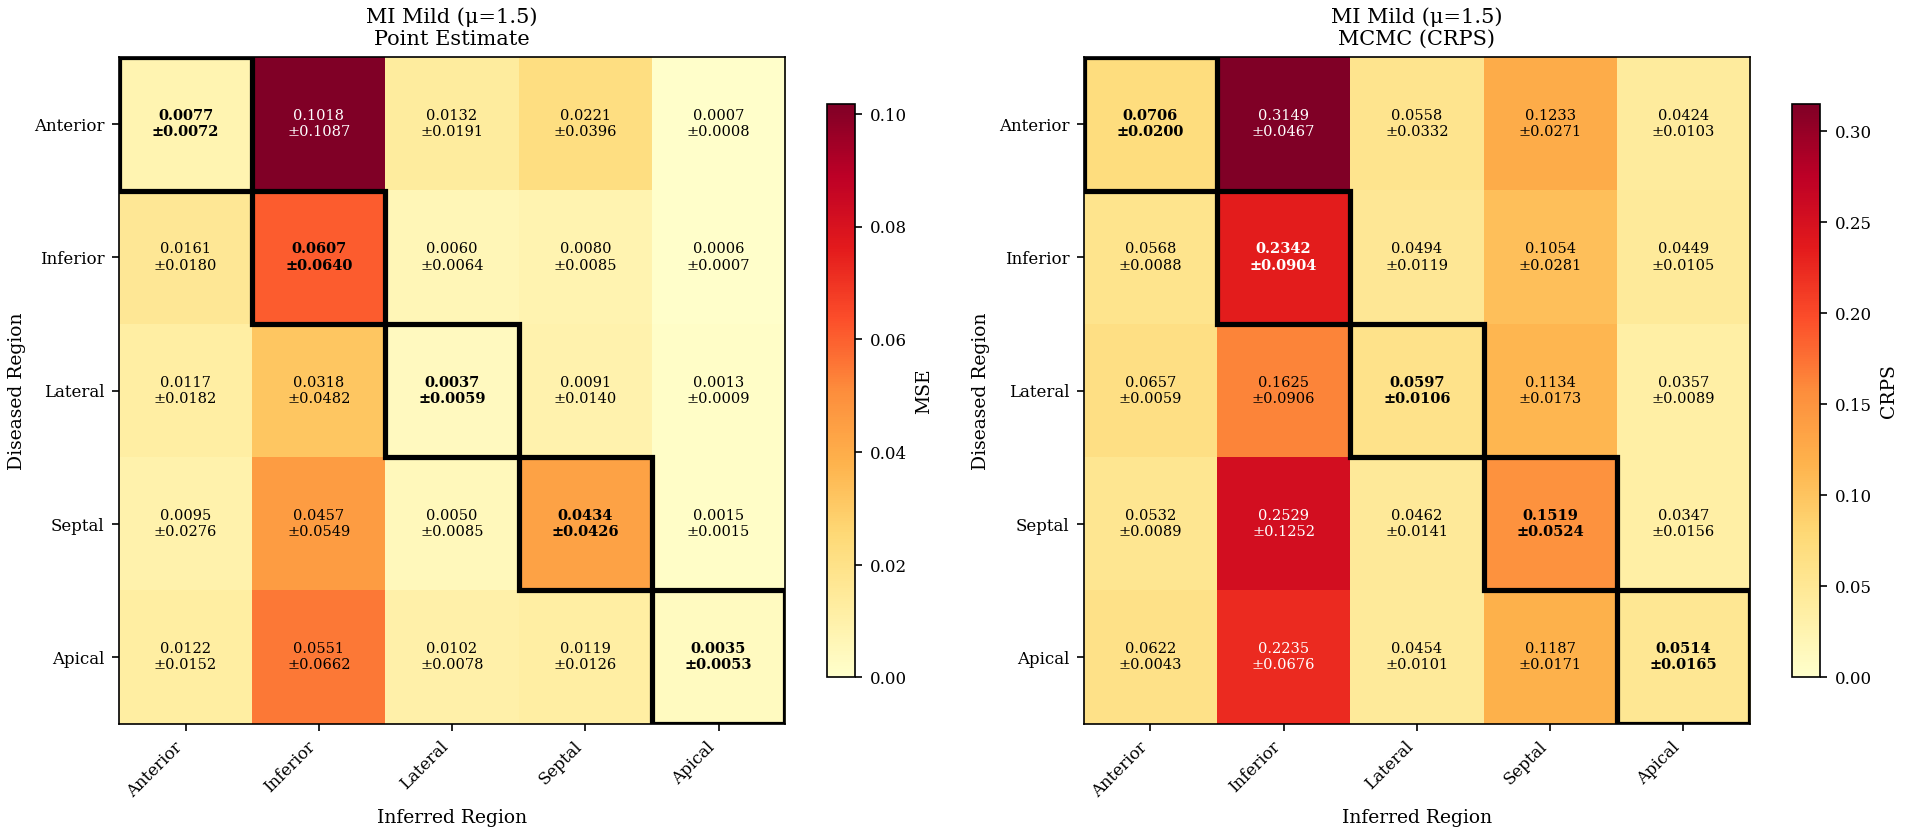

💾 Saved cross-error for MI_2


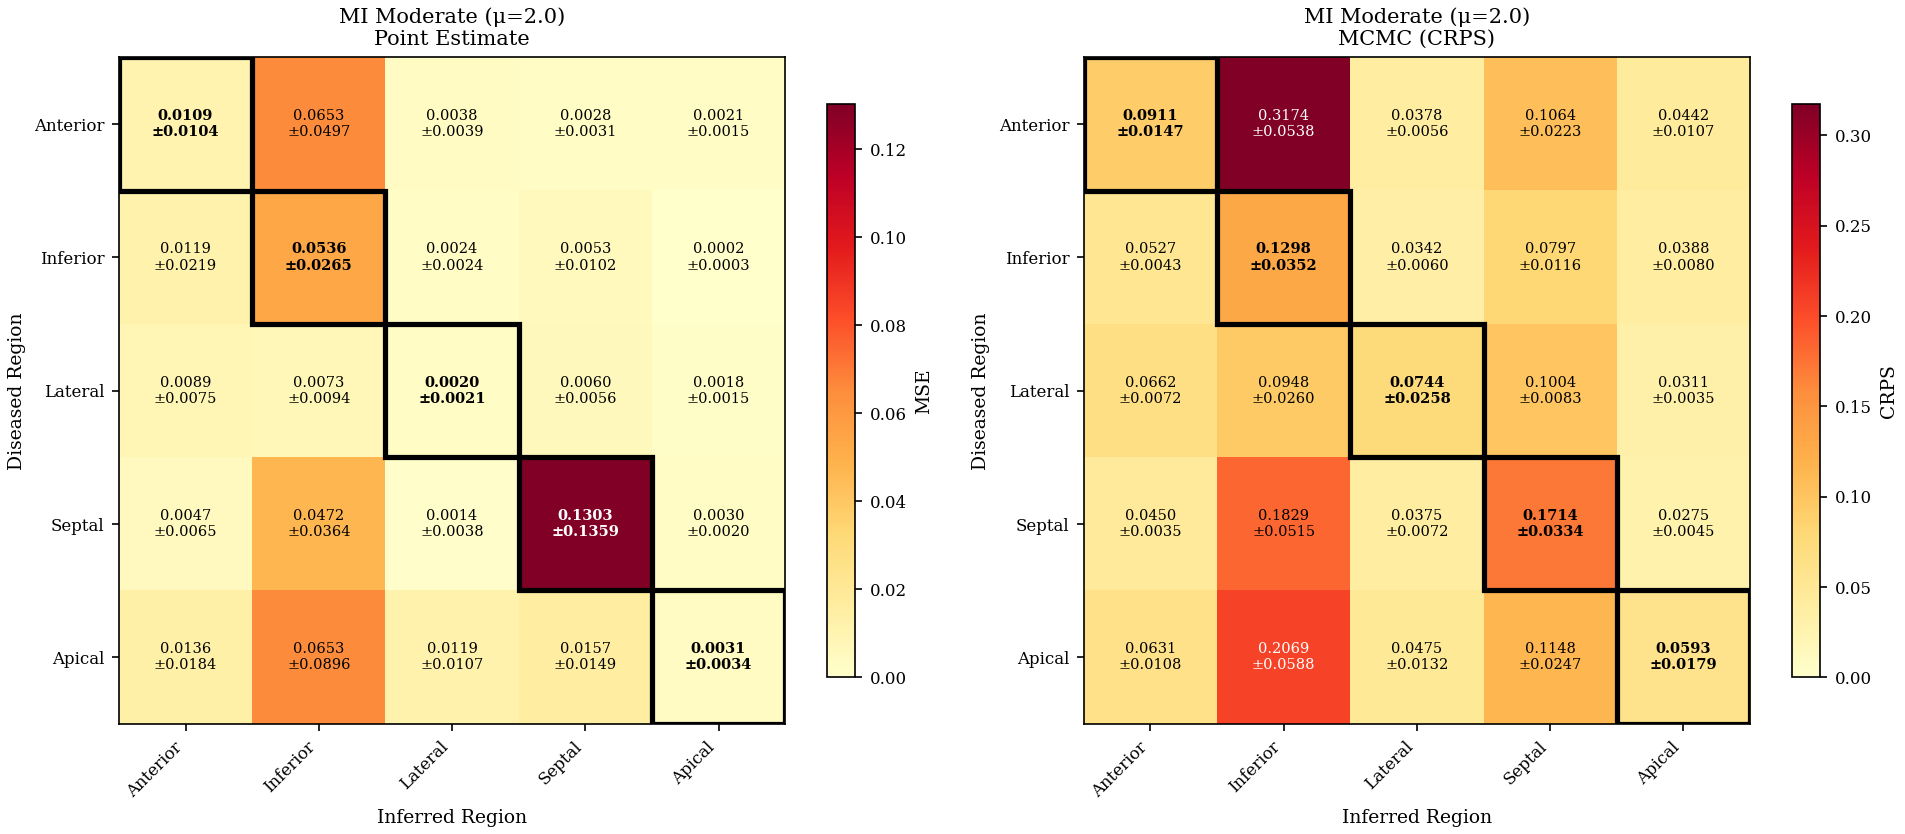

💾 Saved cross-error for MI_3


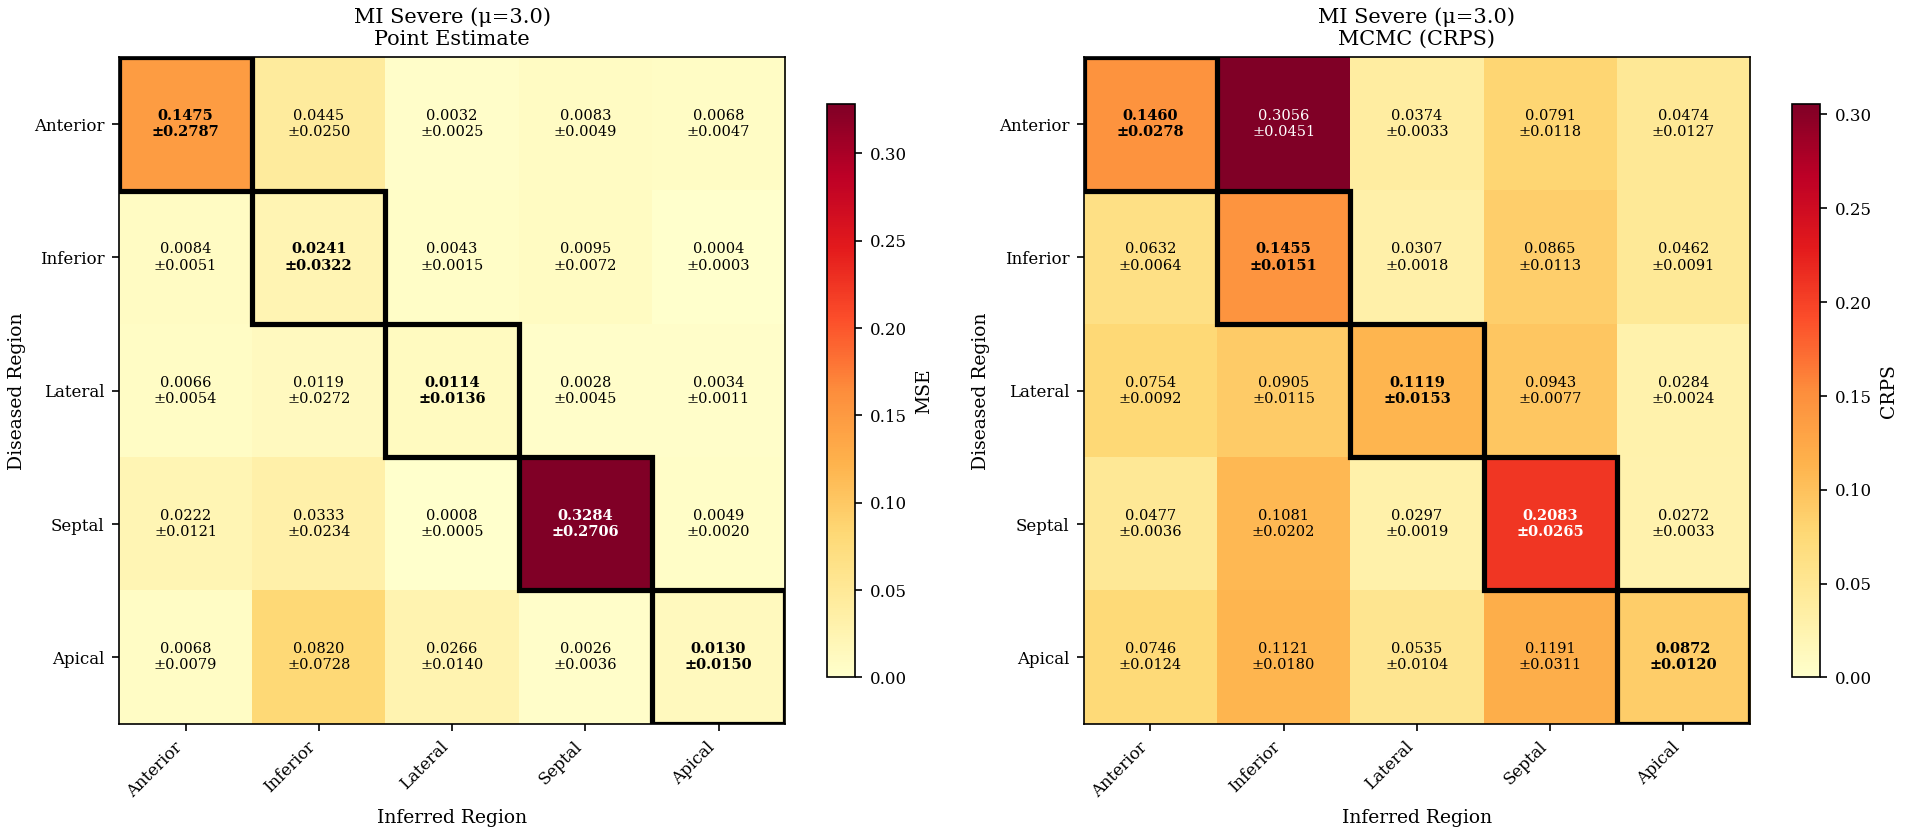

In [19]:
# ══════════════════════════════════════════════════════════════
# 绘制交叉误差矩阵: PE (MSE) 和 MCMC (CRPS) 并排
# ══════════════════════════════════════════════════════════════

for scenario in LOCAL_MI_SCENARIOS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    
    # PE — MSE
    m1, s1 = build_cross_error_matrix(df_errors, scenario, "Point Estimate", "mse")
    plot_cross_error_heatmap(m1, s1,
        f"{SCENARIO_DISPLAY[scenario]}\nPoint Estimate", "MSE", ax=axes[0])
    
    # MCMC — CRPS
    m2, s2 = build_cross_error_matrix(df_errors, scenario, "MCMC", "crps")
    plot_cross_error_heatmap(m2, s2,
        f"{SCENARIO_DISPLAY[scenario]}\nMCMC (CRPS)", "CRPS", ax=axes[1])
    
    plt.tight_layout()
    fig.savefig(Path(OUTPUT_DIR) / f"cross_error_{scenario}.png", bbox_inches="tight")
    print(f"💾 Saved cross-error for {scenario}")
    plt.show()

### 5b. 行/列边际分析 + 对角 vs 非对角提取交叉误差矩阵的边际统计：- **行均值**: 某区域病变时的全局影响（误差传播源）- **列均值**: 某区域的固有推断困难度- **对角线 vs 非对角线**: 病变区域自身误差 vs 误差溢出

In [20]:
marginal_records = []
print("Cross-Error Marginal Analysis (CRPS)")
print("=" * 72)

for scenario in LOCAL_MI_SCENARIOS:
    mean_mat, _ = build_cross_error_matrix(df_errors, scenario, "MCMC", "crps")
    if np.all(np.isnan(mean_mat)):
        continue
    
    diag = np.diag(mean_mat)
    row_means = np.nanmean(mean_mat, axis=1)
    col_means = np.nanmean(mean_mat, axis=0)
    off_diag_row = (np.nansum(mean_mat, axis=1) - diag) / (N_REGIONS - 1)
    
    print(f"\n{SCENARIO_DISPLAY[scenario]}:")
    print(f"  {'Region':<12} {'Diag':>8} {'OffDiag':>8} {'RowMean':>8} {'ColMean':>8}")
    print(f"  {'-'*48}")
    for r in range(N_REGIONS):
        print(f"  {REGION_LABELS[r]:<12} {diag[r]:>8.4f} {off_diag_row[r]:>8.4f} "
              f"{row_means[r]:>8.4f} {col_means[r]:>8.4f}")
        marginal_records.append({
            "scenario": scenario, "metric": "CRPS", "region": REGION_LABELS[r],
            "diagonal": diag[r], "off_diag_mean": off_diag_row[r],
            "row_mean": row_means[r], "col_mean": col_means[r],
        })

df_marginal = pd.DataFrame(marginal_records)
df_marginal.to_csv(Path(CSV_DIR) / "cross_error_marginals.csv", index=False, float_format="%.6f")
print(f"\n✅ Saved: {CSV_DIR}/cross_error_marginals.csv")

Cross-Error Marginal Analysis (CRPS)

MI Mild (μ=1.5):
  Region           Diag  OffDiag  RowMean  ColMean
  ------------------------------------------------
  Anterior       0.0706   0.1341   0.1214   0.0617
  Inferior       0.2342   0.0641   0.0981   0.2376
  Lateral        0.0597   0.0943   0.0874   0.0513
  Septal         0.1519   0.0967   0.1078   0.1225
  Apical         0.0514   0.1125   0.1002   0.0418

MI Moderate (μ=2.0):
  Region           Diag  OffDiag  RowMean  ColMean
  ------------------------------------------------
  Anterior       0.0911   0.1264   0.1194   0.0636
  Inferior       0.1298   0.0513   0.0670   0.1863
  Lateral        0.0744   0.0731   0.0734   0.0463
  Septal         0.1714   0.0732   0.0928   0.1145
  Apical         0.0593   0.1081   0.0983   0.0402

MI Severe (μ=3.0):
  Region           Diag  OffDiag  RowMean  ColMean
  ------------------------------------------------
  Anterior       0.1460   0.1174   0.1231   0.0814
  Inferior       0.1455   0.0567   0

---## 6. 区域误差分布箱线图### 两类指标并排- **PE**: MSE 分布- **MCMC**: CRPS 分布两者在同一 y 轴下可比较（CRPS 在点估计退化时 = MAE，量级与 $\sqrt{\text{MSE}}$ 相当）。

In [21]:
def plot_grouped_boxplot(df, method, metric, ylabel, scenarios=None, save_path=None):
    """Grouped boxplot: x = region, hue = severity."""
    if scenarios is None:
        scenarios = LOCAL_MI_SCENARIOS
    df_plot = df[(df["method"] == method) & (df["scenario"].isin(scenarios))].copy()
    if len(df_plot) == 0:
        print(f"No data for {method}/{metric}")
        return
    
    df_plot["Severity"] = df_plot["scenario"].map(SCENARIO_DISPLAY)
    fig, ax = plt.subplots(figsize=(10, 5))
    palette = {SCENARIO_DISPLAY[s]: c for s, c in zip(
        LOCAL_MI_SCENARIOS, sns.color_palette("YlOrRd_d", 3))}
    
    sns.boxplot(data=df_plot, x="inferred_region", y=metric,
                hue="Severity", order=REGION_LABELS, palette=palette, ax=ax,
                flierprops=dict(marker="o", markersize=3, alpha=0.4), linewidth=0.8)
    
    ax.set_xlabel("Region")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Regional {ylabel} by Severity — {method}", fontsize=11)
    ax.legend(title="Severity", fontsize=8, title_fontsize=9)
    
    yvals = df_plot[metric].dropna()
    if len(yvals) > 0 and yvals.max() / (yvals.median() + 1e-12) > 20:
        ax.set_yscale("log")
        ax.set_ylabel(f"{ylabel} (log scale)")
    
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
        print(f"💾 Saved: {save_path}")
    plt.show()

💾 Saved: LocalDisease\figures_error\boxplot_pe_mse.png


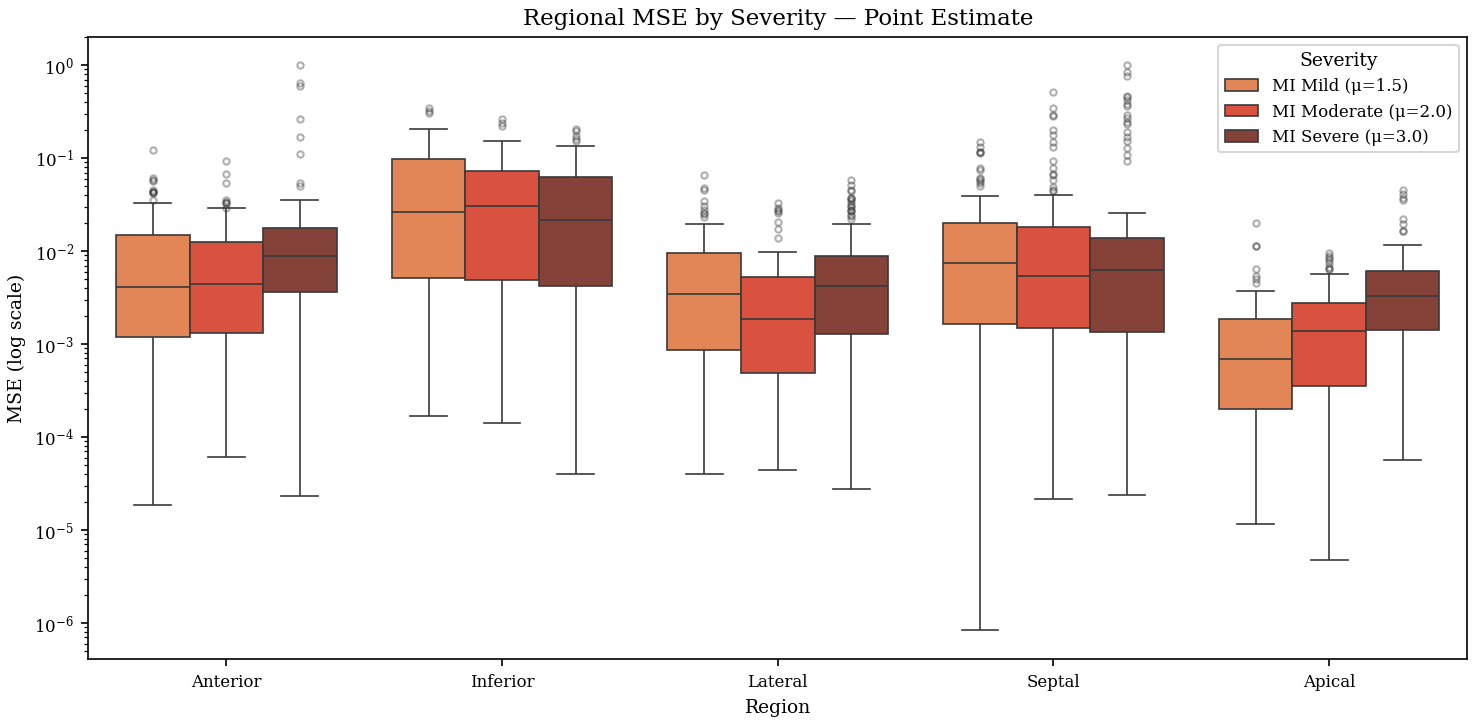

💾 Saved: LocalDisease\figures_error\boxplot_mcmc_crps.png


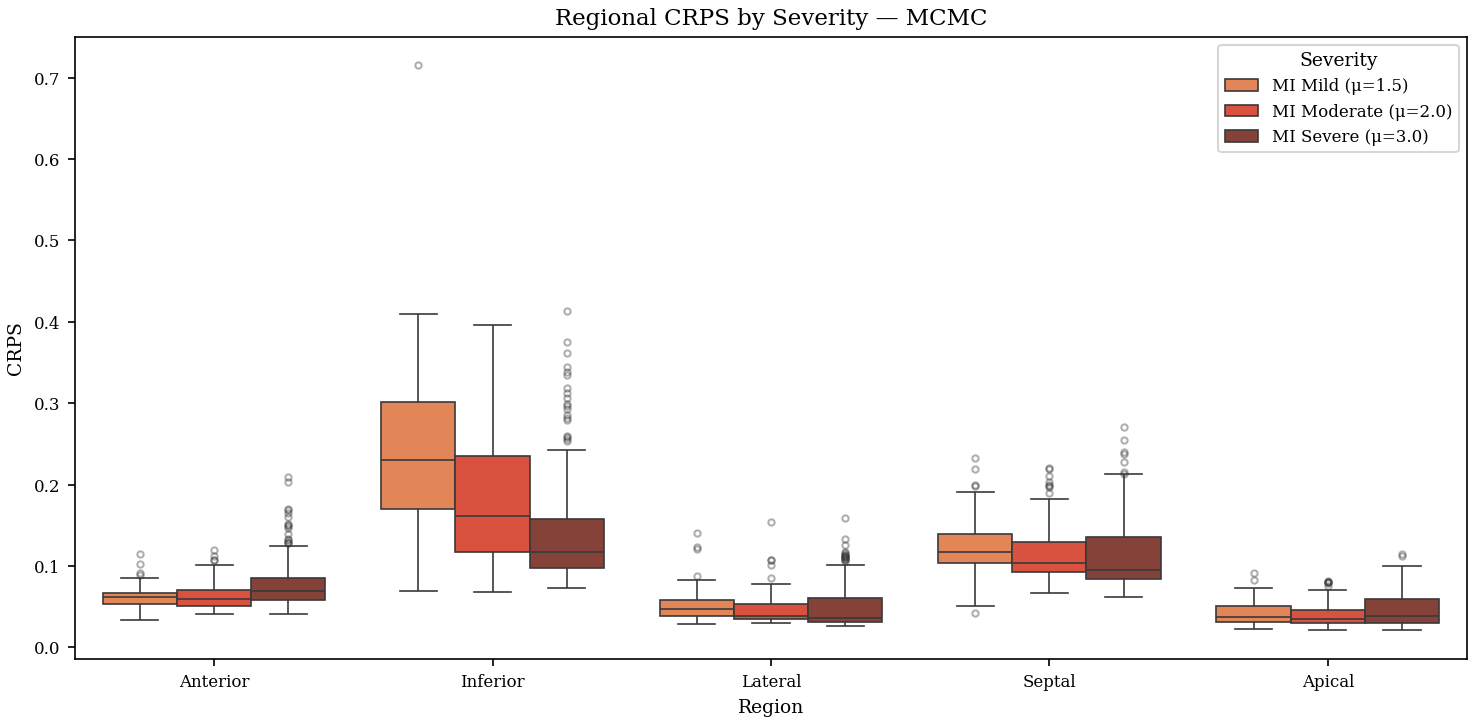

💾 Saved: LocalDisease\figures_error\boxplot_mcmc_ci_width.png


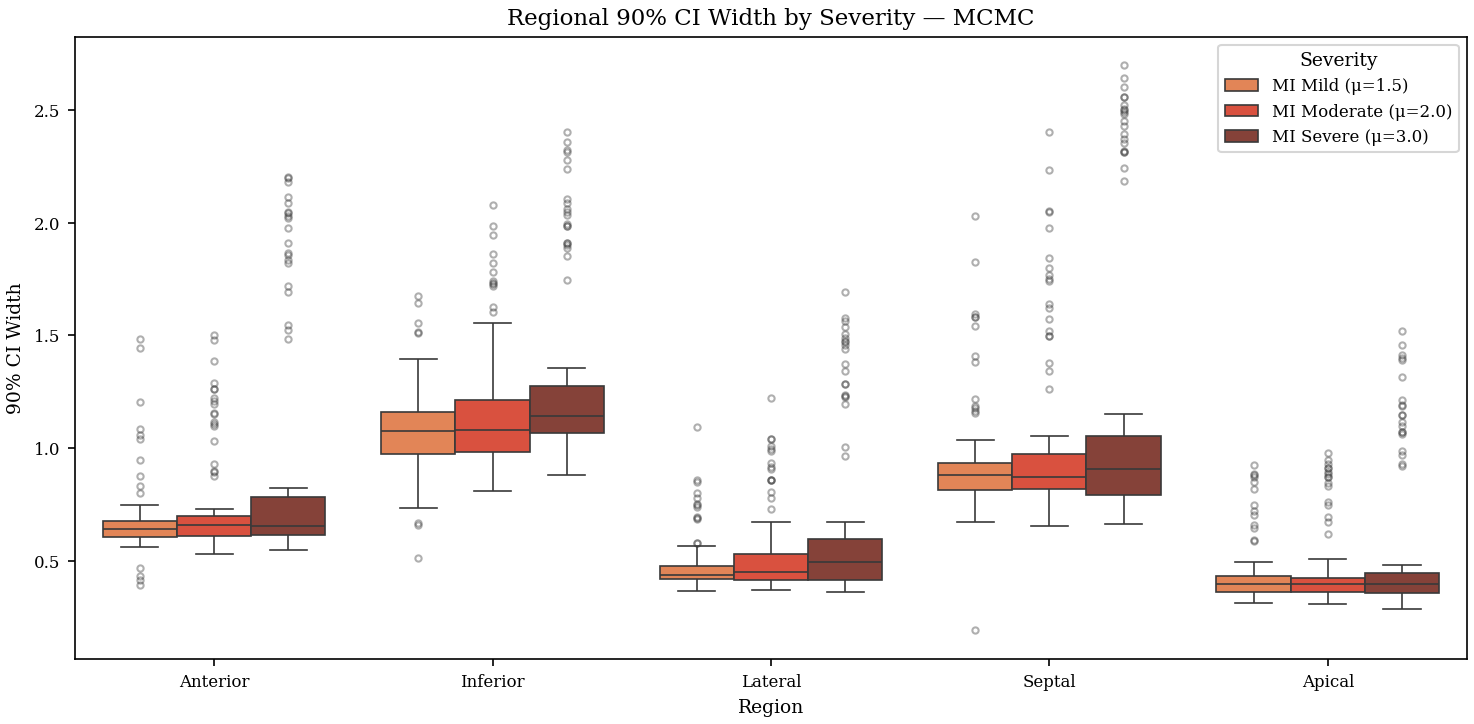

💾 Saved: LocalDisease\figures_error\boxplot_mcmc_interval_score.png


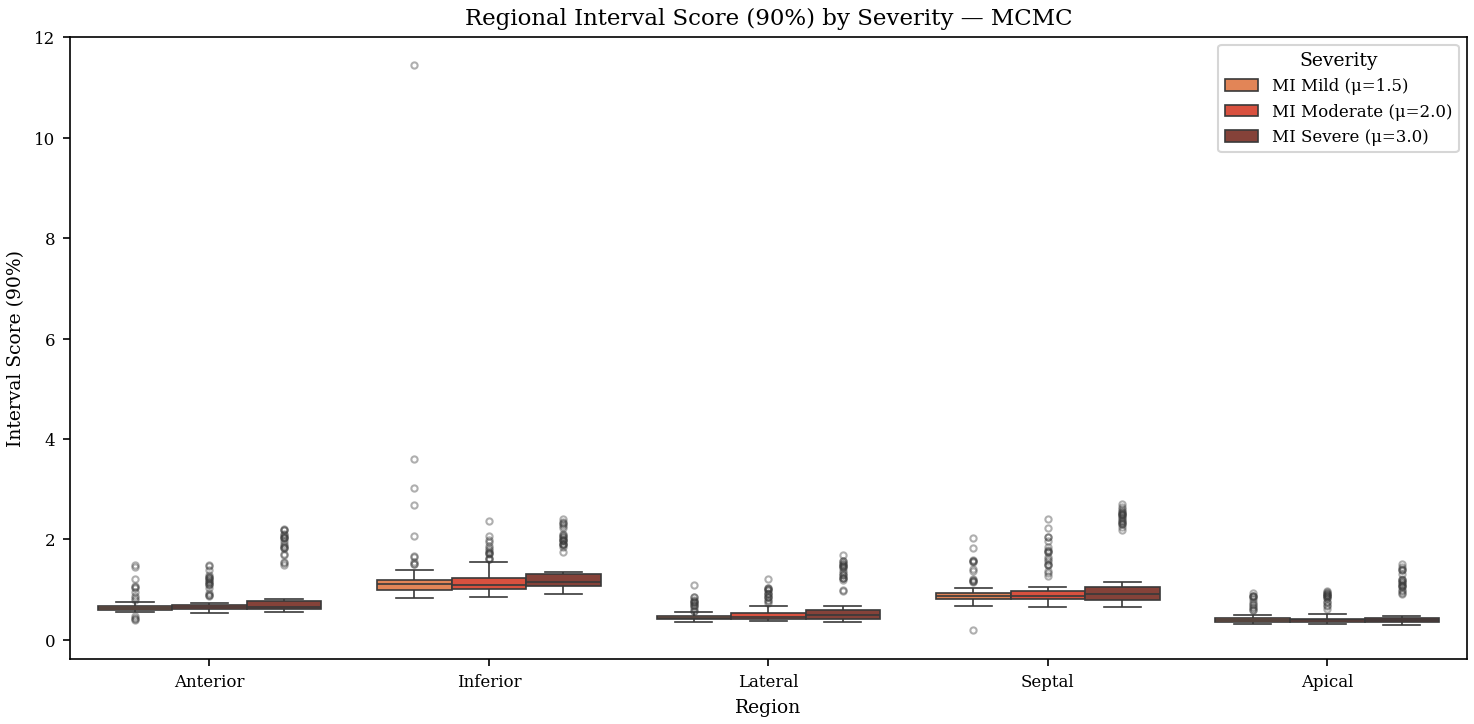

In [22]:
# PE MSE
plot_grouped_boxplot(df_errors, "Point Estimate", "mse", "MSE",
                     save_path=Path(OUTPUT_DIR) / "boxplot_pe_mse.png")

# MCMC CRPS
plot_grouped_boxplot(df_errors, "MCMC", "crps", "CRPS",
                     save_path=Path(OUTPUT_DIR) / "boxplot_mcmc_crps.png")

# MCMC CI Width (sharpness)
plot_grouped_boxplot(df_errors, "MCMC", "ci_width", "90% CI Width",
                     save_path=Path(OUTPUT_DIR) / "boxplot_mcmc_ci_width.png")

# MCMC Interval Score
plot_grouped_boxplot(df_errors, "MCMC", "interval_score", "Interval Score (90%)",
                     save_path=Path(OUTPUT_DIR) / "boxplot_mcmc_interval_score.png")

---## 7. 点估计 vs MCMC 对比### 公平比较策略| PE 指标 | MCMC 对应 | 比较方式 ||---------|-----------|----------|| MAE | CRPS | 直接比较（CRPS of point mass = MAE） || MSE | Median MSE | 参考比较（不推荐作为主要结论） |**CRPS 是唯一公平的跨方法比较指标**：它对 MCMC 利用了完整后验信息，同时在退化为点质量时自动回退为 MAE。### 分析内容1. **CRPS scatter**: x = PE CRPS (= MAE), y = MCMC CRPS, 45° 线以下 = MCMC 胜2. **Per-region scatter**: 观察各区域的 MCMC 收益3. **MCMC 改善率热力图**: `(CRPS_PE − CRPS_MCMC) / CRPS_PE`4. **Wilcoxon signed-rank test**: 配对差异的统计显著性

In [23]:
# ══════════════════════════════════════════════════════════════
# 构建 paired comparison DataFrame (PE MAE vs MCMC CRPS)
# ══════════════════════════════════════════════════════════════

df_pe = df_errors[df_errors["method"] == "Point Estimate"].copy()
df_mc = df_errors[df_errors["method"] == "MCMC"].copy()

merge_keys = ["scenario", "sample_idx", "inferred_region", "inferred_region_idx",
              "target_region", "target_region_idx"]

df_paired = pd.merge(
    df_pe[merge_keys + ["mse", "mae", "crps"]].rename(
        columns={"mse": "pe_mse", "mae": "pe_mae", "crps": "pe_crps"}),
    df_mc[merge_keys + ["crps", "interval_score", "ci_width", "coverage", "median_mse"]].rename(
        columns={"crps": "mcmc_crps", "median_mse": "mcmc_median_mse"}),
    on=merge_keys,
)

# CRPS 改善率 (正值 = MCMC 更好)
df_paired["crps_improvement"] = (
    (df_paired["pe_crps"] - df_paired["mcmc_crps"]) / (df_paired["pe_crps"] + 1e-12)
)
df_paired["scenario_display"] = df_paired["scenario"].map(SCENARIO_DISPLAY)

print(f"✅ Paired DataFrame: {len(df_paired)} rows")
df_paired.head()

✅ Paired DataFrame: 2000 rows


,scenario,sample_idx,inferred_region,inferred_region_idx,target_region,target_region_idx,pe_mse,pe_mae,pe_crps,mcmc_crps,interval_score,ci_width,coverage,mcmc_median_mse,crps_improvement,scenario_display
0,HCM,0,Anterior,0,Global,-1,0.005832,0.075864,0.075864,0.072843,0.984756,0.984756,1.0,0.000814,0.039820,"HCM (Global, μ=1.7)"
1,HCM,0,Inferior,1,Global,-1,0.218405,0.460601,0.460601,0.111257,1.498845,1.498845,1.0,0.010653,0.758453,"HCM (Global, μ=1.7)"
2,HCM,0,Lateral,2,Global,-1,0.005297,0.072387,0.072387,0.045183,0.642030,0.642030,1.0,0.000045,0.375818,"HCM (Global, μ=1.7)"
3,HCM,0,Septal,3,Global,-1,0.022080,0.145338,0.145338,0.147525,1.355235,1.355235,1.0,0.047774,-0.015047,"HCM (Global, μ=1.7)"
4,HCM,0,Apical,4,Global,-1,0.000188,0.010724,0.010724,0.042034,0.589208,0.589208,1.0,0.000013,-2.919457,"HCM (Global, μ=1.7)"


💾 Saved: LocalDisease/figures_error/scatter_crps_pe_vs_mcmc.png


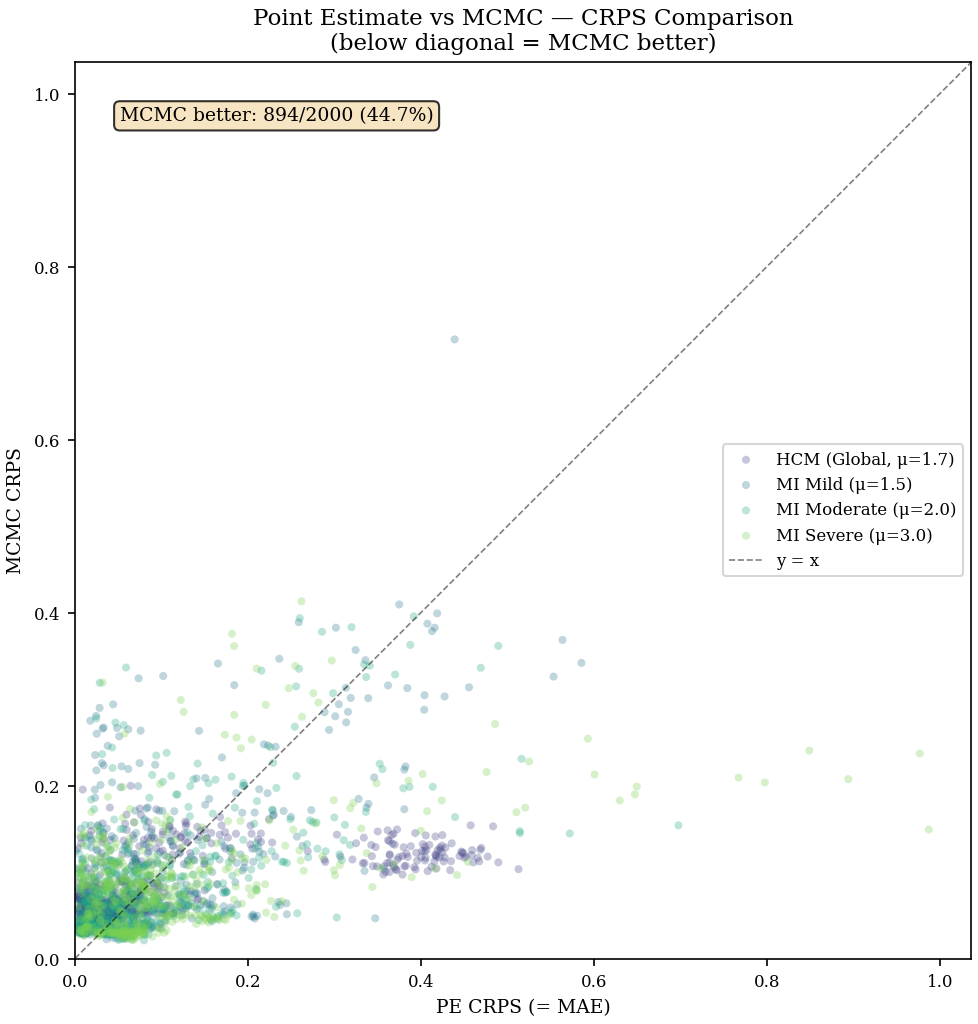

In [24]:
# ══════════════════════════════════════════════════════════════
# 6a. CRPS Scatter: PE (=MAE) vs MCMC
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(7, 7))
palette = sns.color_palette("viridis", len(SCENARIOS))
colors = {s: c for s, c in zip(SCENARIOS, palette)}

for scenario in SCENARIOS:
    df_s = df_paired[df_paired["scenario"] == scenario]
    ax.scatter(df_s["pe_crps"], df_s["mcmc_crps"],
               alpha=0.3, s=15, color=colors[scenario],
               label=SCENARIO_DISPLAY[scenario], edgecolors="none")

max_val = max(df_paired["pe_crps"].max(), df_paired["mcmc_crps"].max())
ax.plot([0, max_val*1.05], [0, max_val*1.05], "k--", lw=0.8, alpha=0.5, label="y = x")
ax.set_xlim(0, max_val * 1.05)
ax.set_ylim(0, max_val * 1.05)
ax.set_xlabel("PE CRPS (= MAE)")
ax.set_ylabel("MCMC CRPS")
ax.set_title("Point Estimate vs MCMC — CRPS Comparison\n(below diagonal = MCMC better)", fontsize=11)
ax.legend(fontsize=8)
ax.set_aspect("equal")

n_mcmc_better = (df_paired["mcmc_crps"] < df_paired["pe_crps"]).sum()
n_total = len(df_paired)
ax.text(0.05, 0.95, f"MCMC better: {n_mcmc_better}/{n_total} ({100*n_mcmc_better/n_total:.1f}%)",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

plt.tight_layout()
fig.savefig(Path(OUTPUT_DIR) / "scatter_crps_pe_vs_mcmc.png")
print(f"💾 Saved: {OUTPUT_DIR}/scatter_crps_pe_vs_mcmc.png")
plt.show()

💾 Saved: LocalDisease/figures_error/scatter_crps_per_region.png


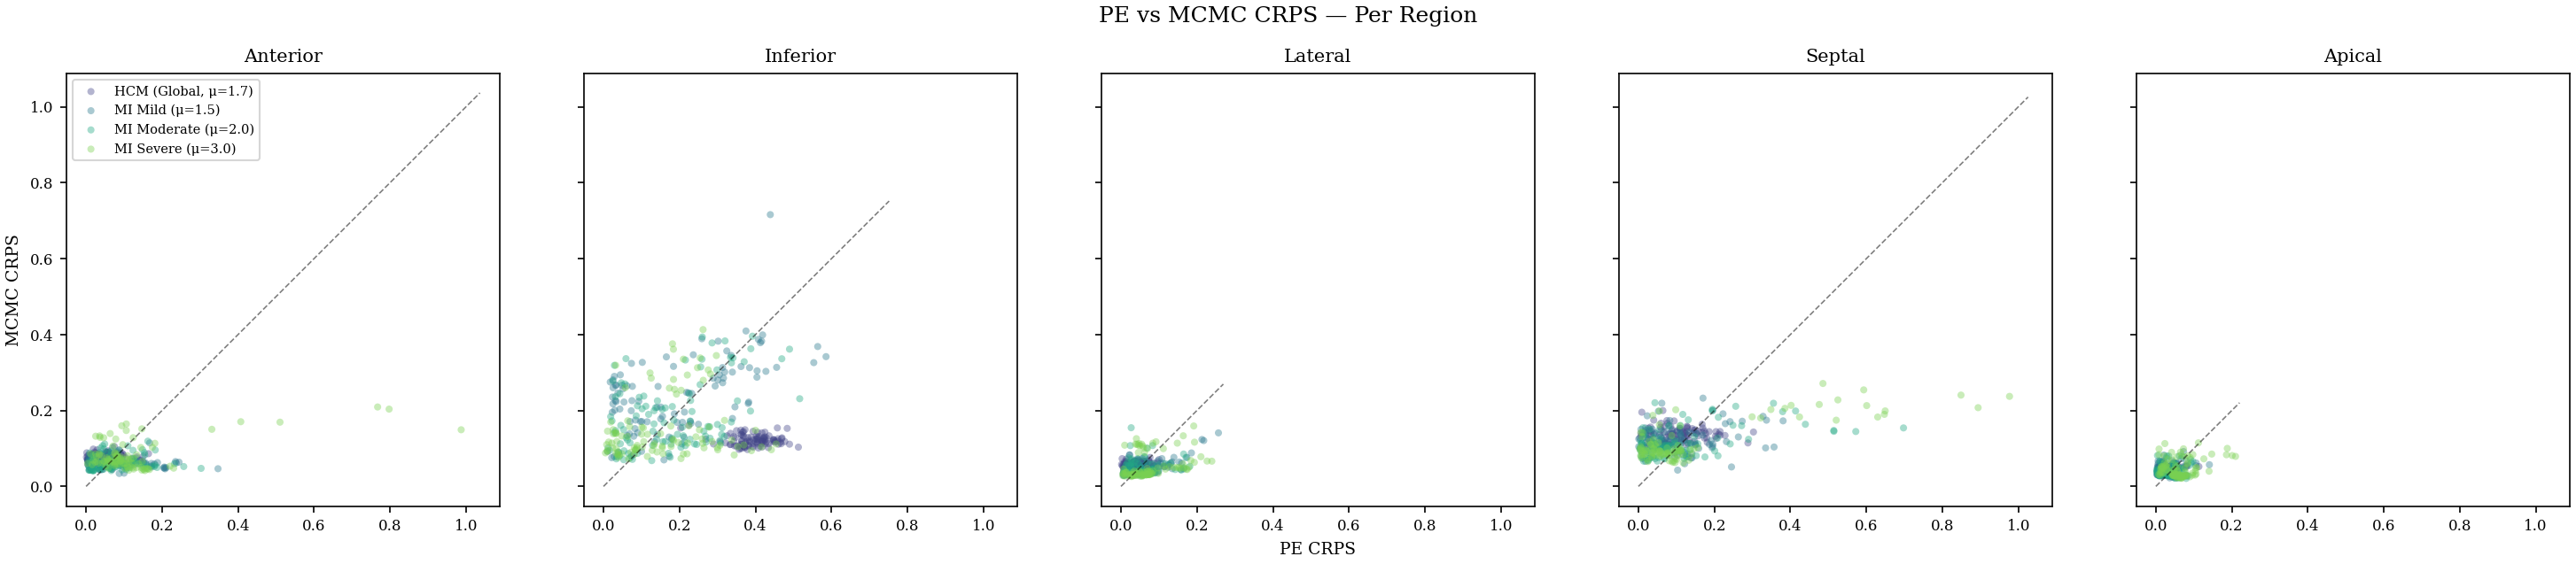

In [25]:
# ══════════════════════════════════════════════════════════════
# 6b. Per-region CRPS scatter
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, N_REGIONS, figsize=(4*N_REGIONS, 4), sharey=True, sharex=True)
palette = sns.color_palette("viridis", len(SCENARIOS))
colors = {s: c for s, c in zip(SCENARIOS, palette)}

for r_idx in range(N_REGIONS):
    ax = axes[r_idx]
    df_r = df_paired[df_paired["inferred_region_idx"] == r_idx]
    
    for scenario in SCENARIOS:
        df_s = df_r[df_r["scenario"] == scenario]
        ax.scatter(df_s["pe_crps"], df_s["mcmc_crps"],
                   alpha=0.4, s=15, color=colors[scenario],
                   label=SCENARIO_DISPLAY[scenario] if r_idx == 0 else None,
                   edgecolors="none")
    
    max_val = max(df_r["pe_crps"].max(), df_r["mcmc_crps"].max()) if len(df_r) > 0 else 1
    ax.plot([0, max_val*1.05], [0, max_val*1.05], "k--", lw=0.8, alpha=0.5)
    ax.set_aspect("equal")
    ax.set_title(REGION_LABELS[r_idx], fontsize=10)
    if r_idx == N_REGIONS // 2:
        ax.set_xlabel("PE CRPS")
    if r_idx == 0:
        ax.set_ylabel("MCMC CRPS")

axes[0].legend(fontsize=7)
fig.suptitle("PE vs MCMC CRPS — Per Region", fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(Path(OUTPUT_DIR) / "scatter_crps_per_region.png", bbox_inches="tight")
print(f"💾 Saved: {OUTPUT_DIR}/scatter_crps_per_region.png")
plt.show()

### 7c. MCMC CRPS 改善率热力图Scenario × Region 的改善率矩阵：`(CRPS_PE − CRPS_MCMC) / CRPS_PE`。  绿色 → MCMC 改善，红色 → PE 反而更好。

💾 Saved: LocalDisease/figures_error/heatmap_crps_improvement.png


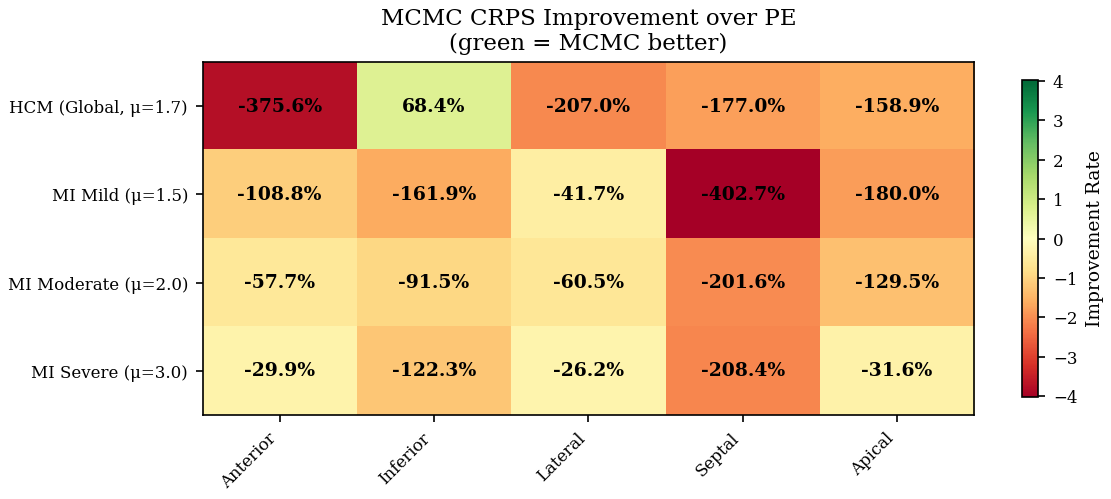

In [26]:
improvement_matrix = np.full((len(SCENARIOS), N_REGIONS), np.nan)
for s_idx, scenario in enumerate(SCENARIOS):
    for r_idx in range(N_REGIONS):
        df_sr = df_paired[(df_paired["scenario"] == scenario) &
                          (df_paired["inferred_region_idx"] == r_idx)]
        if len(df_sr) > 0:
            improvement_matrix[s_idx, r_idx] = df_sr["crps_improvement"].mean()

fig, ax = plt.subplots(figsize=(8, 3.5))
vabs = max(abs(np.nanmin(improvement_matrix)), abs(np.nanmax(improvement_matrix)), 0.01)
norm = TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)
im = ax.imshow(improvement_matrix, cmap="RdYlGn", norm=norm, aspect="auto")

for i in range(len(SCENARIOS)):
    for j in range(N_REGIONS):
        val = improvement_matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val*100:.1f}%", ha="center", va="center", fontsize=9,
                    fontweight="bold" if abs(val) > 0.1 else "normal")

ax.set_xticks(range(N_REGIONS))
ax.set_xticklabels(REGION_LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(SCENARIOS)))
ax.set_yticklabels([SCENARIO_DISPLAY[s] for s in SCENARIOS])
ax.set_title("MCMC CRPS Improvement over PE\n(green = MCMC better)", fontsize=11)
plt.colorbar(im, ax=ax, label="Improvement Rate", shrink=0.9)

plt.tight_layout()
fig.savefig(Path(OUTPUT_DIR) / "heatmap_crps_improvement.png")
print(f"💾 Saved: {OUTPUT_DIR}/heatmap_crps_improvement.png")
plt.show()

### 7d. Wilcoxon Signed-Rank Test配对比较 PE CRPS vs MCMC CRPS 是否有统计显著差异。

In [28]:
from scipy import stats

print("Wilcoxon Signed-Rank Test: PE CRPS (=MAE) vs MCMC CRPS")
print("=" * 78)
print(f"{'Scenario':<25} {'Region':<12} {'med ΔCRPS':>10} {'W-stat':>10} {'p-value':>10} {'Sig':>5}")
print("-" * 78)

test_records = []
for scenario in SCENARIOS:
    for r_idx in range(N_REGIONS):
        df_sr = df_paired[(df_paired["scenario"] == scenario) &
                          (df_paired["inferred_region_idx"] == r_idx)]
        if len(df_sr) < 5:
            continue
        diff = df_sr["pe_crps"].values - df_sr["mcmc_crps"].values
        nonzero = diff[diff != 0]
        if len(nonzero) < 5:
            continue
        
        stat, pval = stats.wilcoxon(nonzero)
        med = np.median(diff)
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
        
        print(f"{SCENARIO_DISPLAY[scenario]:<25} {REGION_LABELS[r_idx]:<12} "
              f"{med:>10.4f} {stat:>10.0f} {pval:>10.4f} {sig:>5}")
        test_records.append({
            "scenario": scenario, "region": REGION_LABELS[r_idx],
            "median_diff_PE_minus_MCMC": med, "W_stat": stat, "p_value": pval, "sig": sig,
        })

pd.DataFrame(test_records).to_csv(
    Path(CSV_DIR) / "wilcoxon_crps_pe_vs_mcmc.csv", index=False, float_format="%.6f")
print(f"\n✅ Saved: {CSV_DIR}/wilcoxon_crps_pe_vs_mcmc.csv")

Wilcoxon Signed-Rank Test: PE CRPS (=MAE) vs MCMC CRPS
Scenario                  Region        med ΔCRPS     W-stat    p-value   Sig
------------------------------------------------------------------------------
HCM (Global, μ=1.7)       Anterior        -0.0321        793     0.0000   ***
HCM (Global, μ=1.7)       Inferior         0.2757          0     0.0000   ***
HCM (Global, μ=1.7)       Lateral         -0.0244        588     0.0000   ***
HCM (Global, μ=1.7)       Septal          -0.0319       1234     0.0000   ***
HCM (Global, μ=1.7)       Apical          -0.0223        407     0.0000   ***
MI Mild (μ=1.5)           Anterior        -0.0024       2177     0.2315    ns
MI Mild (μ=1.5)           Inferior        -0.0309       1611     0.0017    **
MI Mild (μ=1.5)           Lateral          0.0065       1554     0.0008   ***
MI Mild (μ=1.5)           Septal          -0.0393       1744     0.0072    **
MI Mild (μ=1.5)           Apical          -0.0132       1198     0.0000   ***
MI Moder

---## 8. MCMC 后验 Calibration 深度分析### 为什么 Calibration 至关重要后验推断的核心承诺是：**90% 可信区间应当在 90% 的情况下覆盖真值**。如果实际覆盖率系统性偏低（undercoverage），说明后验过度自信，可能因为模型缺陷或 MCMC 收敛不足。如果系统性偏高（overcoverage），说明后验过于保守。### 分析内容1. **Reliability Diagram（校准图）**: 理想校准下所有点应落在 45° 线上2. **Per-Region 校准**: 各区域是否存在系统性偏差3. **Per-Severity 校准**: 随疾病加重，后验是否变得更不可靠4. **校准误差热力图**: Scenario × Region 的 |实际覆盖 − 名义覆盖| 矩阵

💾 Saved: LocalDisease\figures_error\reliability_global.png


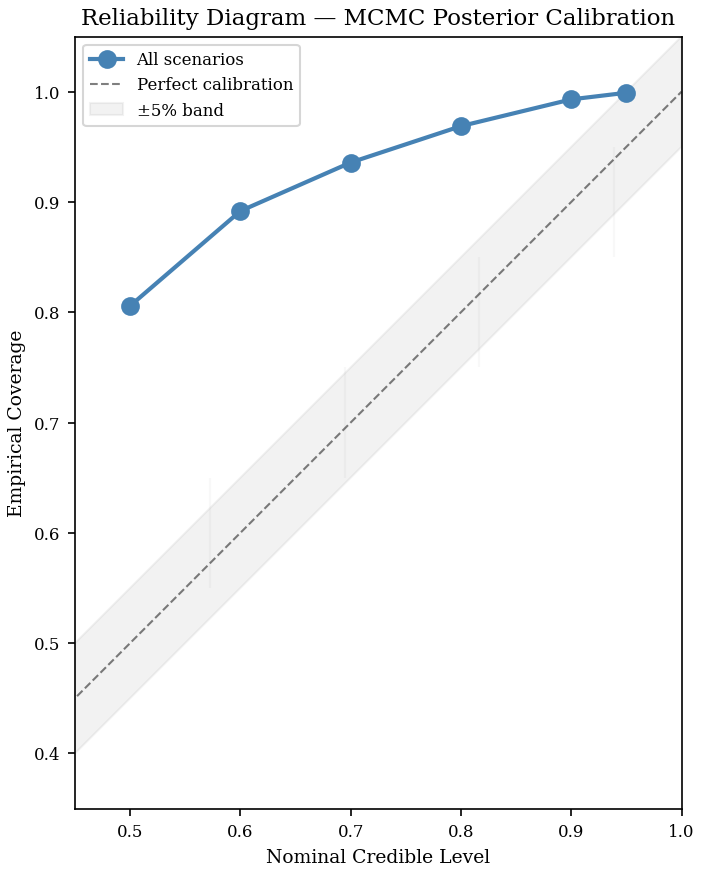

💾 Saved: LocalDisease\figures_error\reliability_by_scenario.png


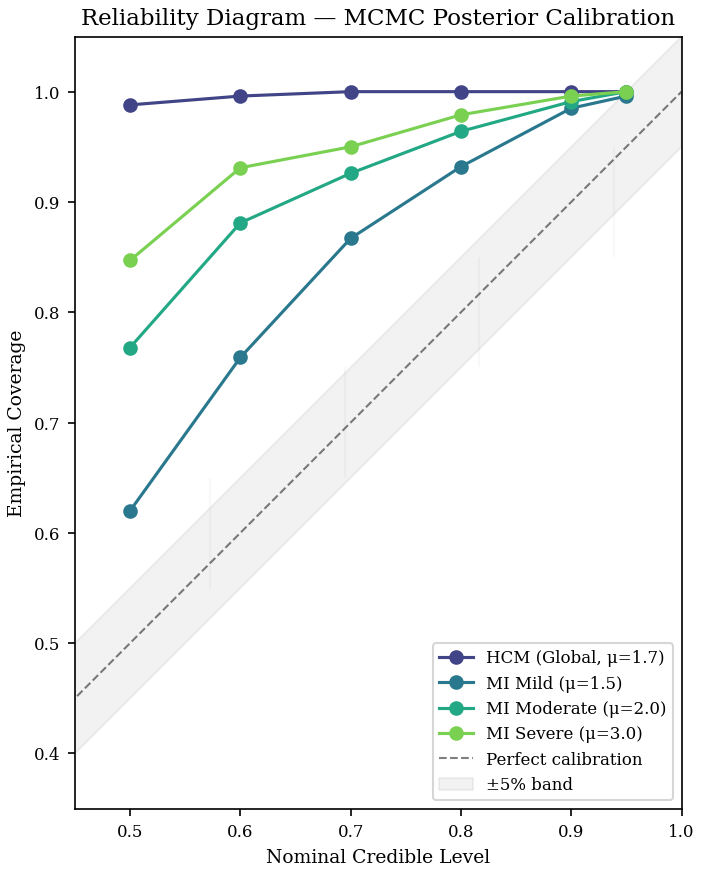

In [29]:
# ══════════════════════════════════════════════════════════════
# 7a. Reliability Diagram — 全局 + 按 scenario 分组
# ══════════════════════════════════════════════════════════════

def plot_reliability_diagram(df_calib, group_col=None, save_path=None):
    """
    Reliability diagram: x = nominal credible level, y = empirical coverage.
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    
    if group_col is None:
        # 全局
        empirical = df_calib.groupby("credible_level")["covered"].mean()
        ax.plot(empirical.index, empirical.values, "o-", color="steelblue",
                linewidth=2, markersize=8, label="All scenarios")
    else:
        palette = sns.color_palette("viridis", df_calib[group_col].nunique())
        for idx, (name, grp) in enumerate(df_calib.groupby(group_col)):
            emp = grp.groupby("credible_level")["covered"].mean()
            label = SCENARIO_DISPLAY.get(name, name) if group_col == "scenario" else name
            ax.plot(emp.index, emp.values, "o-", color=palette[idx],
                    linewidth=1.5, markersize=6, label=label)
    
    # 理想线
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Perfect calibration")
    
    # ±5% band
    for lv in CREDIBLE_LEVELS:
        ax.axhspan(lv - 0.05, lv + 0.05, xmin=(lv - CREDIBLE_LEVELS[0]) / (CREDIBLE_LEVELS[-1] - CREDIBLE_LEVELS[0]),
                    xmax=(lv - CREDIBLE_LEVELS[0]) / (CREDIBLE_LEVELS[-1] - CREDIBLE_LEVELS[0]),
                    alpha=0.05, color="grey")
    ax.fill_between([0, 1], [0-0.05, 1-0.05], [0+0.05, 1+0.05],
                     alpha=0.1, color="grey", label="±5% band")
    
    ax.set_xlabel("Nominal Credible Level")
    ax.set_ylabel("Empirical Coverage")
    ax.set_title("Reliability Diagram — MCMC Posterior Calibration", fontsize=11)
    ax.set_xlim(CREDIBLE_LEVELS[0] - 0.05, CREDIBLE_LEVELS[-1] + 0.05)
    ax.set_ylim(CREDIBLE_LEVELS[0] - 0.15, 1.05)
    ax.legend(fontsize=8)
    ax.set_aspect("equal")
    
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
        print(f"💾 Saved: {save_path}")
    plt.show()

# 全局 reliability diagram
plot_reliability_diagram(df_calib, group_col=None,
                          save_path=Path(OUTPUT_DIR) / "reliability_global.png")

# 按 scenario 分组
plot_reliability_diagram(df_calib, group_col="scenario",
                          save_path=Path(OUTPUT_DIR) / "reliability_by_scenario.png")

💾 Saved: LocalDisease/figures_error/reliability_per_region.png


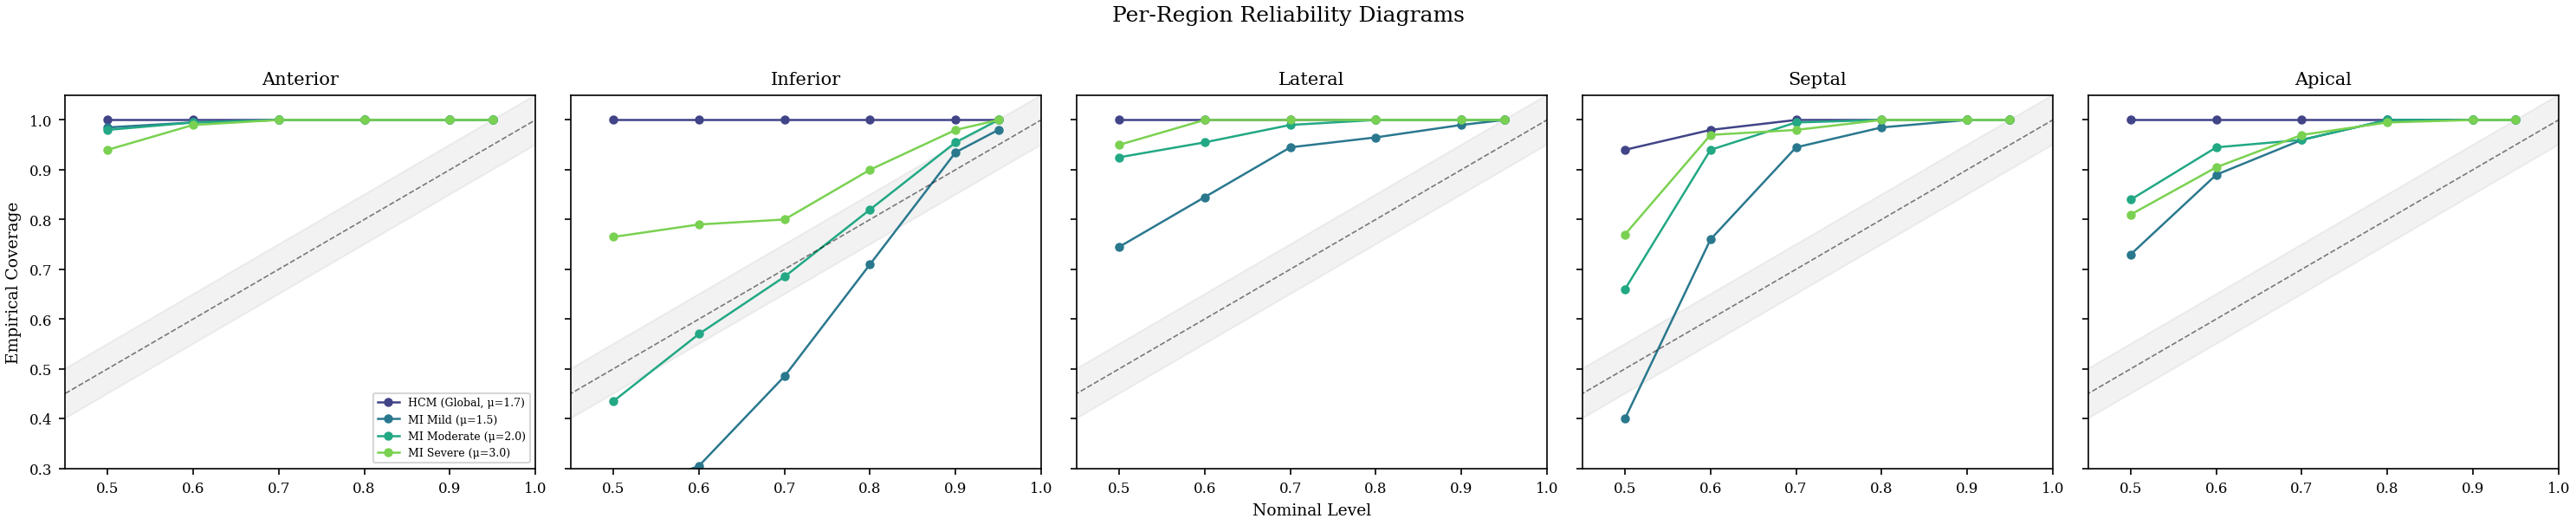

In [30]:
# ══════════════════════════════════════════════════════════════
# 7b. Per-Region Reliability Diagram
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, N_REGIONS, figsize=(4*N_REGIONS, 4), sharey=True)
palette = sns.color_palette("viridis", len(SCENARIOS))

for r_idx in range(N_REGIONS):
    ax = axes[r_idx]
    df_r = df_calib[df_calib["inferred_region_idx"] == r_idx]
    
    for s_idx, scenario in enumerate(SCENARIOS):
        df_rs = df_r[df_r["scenario"] == scenario]
        emp = df_rs.groupby("credible_level")["covered"].mean()
        ax.plot(emp.index, emp.values, "o-", color=palette[s_idx],
                linewidth=1.2, markersize=4,
                label=SCENARIO_DISPLAY[scenario] if r_idx == 0 else None)
    
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
    ax.fill_between([0, 1], [-0.05, 0.95], [0.05, 1.05], alpha=0.1, color="grey")
    ax.set_title(REGION_LABELS[r_idx], fontsize=10)
    ax.set_xlabel("Nominal Level" if r_idx == N_REGIONS//2 else "")
    if r_idx == 0:
        ax.set_ylabel("Empirical Coverage")
    ax.set_xlim(0.45, 1.0)
    ax.set_ylim(0.3, 1.05)

axes[0].legend(fontsize=6)
fig.suptitle("Per-Region Reliability Diagrams", fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(Path(OUTPUT_DIR) / "reliability_per_region.png", bbox_inches="tight")
print(f"💾 Saved: {OUTPUT_DIR}/reliability_per_region.png")
plt.show()

### 8c. 校准误差热力图对 90% 可信水平，构建 scenario × region 的校准误差矩阵：  `Calibration Error = |Empirical Coverage − 0.90|`高值（深色）表示后验在该条件下严重失准。

💾 Saved: LocalDisease/figures_error/calibration_heatmap.png


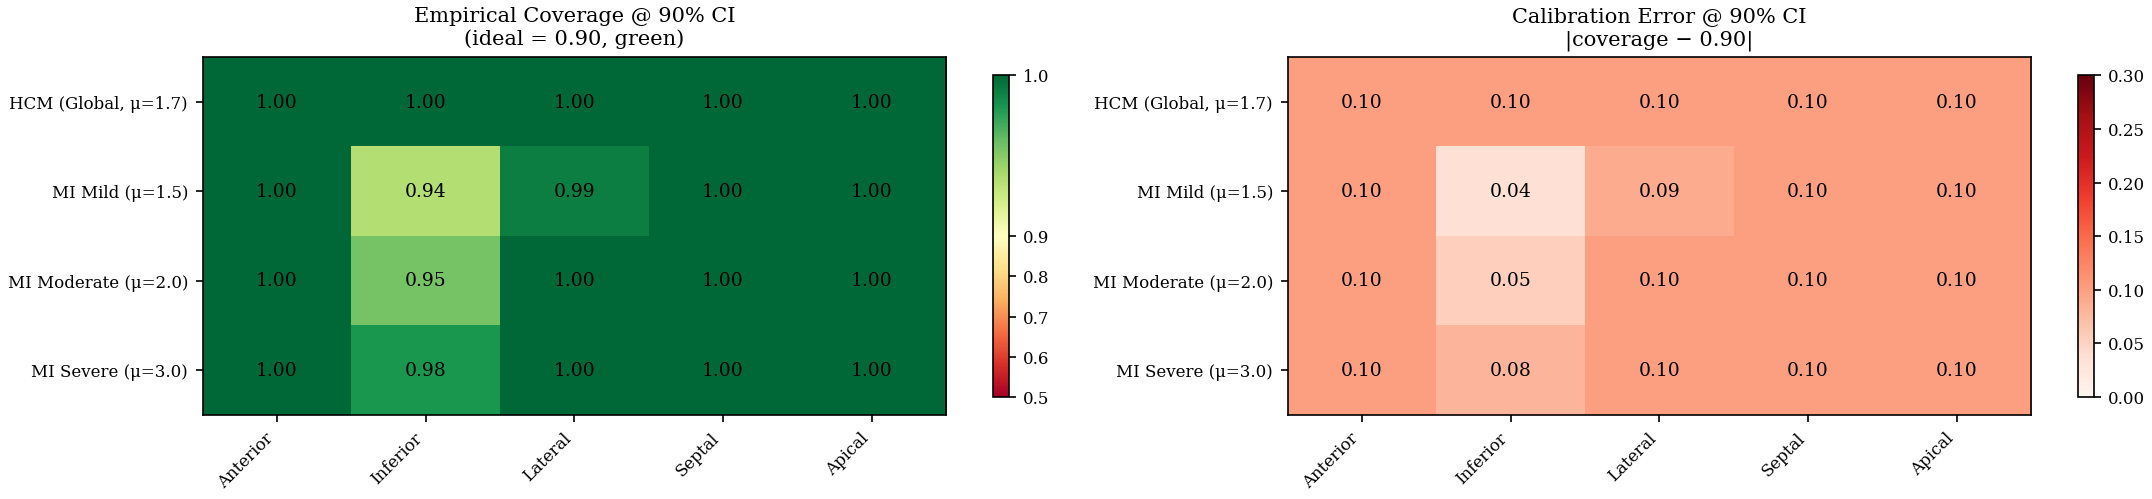

In [31]:
# ══════════════════════════════════════════════════════════════
# 7c. Calibration Error 热力图: scenario × region @ 90% CI
# ══════════════════════════════════════════════════════════════

calib_90 = df_calib[df_calib["credible_level"] == 0.90].copy()
calib_matrix = np.full((len(SCENARIOS), N_REGIONS), np.nan)
coverage_matrix = np.full((len(SCENARIOS), N_REGIONS), np.nan)

for s_idx, scenario in enumerate(SCENARIOS):
    for r_idx in range(N_REGIONS):
        df_sr = calib_90[(calib_90["scenario"] == scenario) &
                         (calib_90["inferred_region_idx"] == r_idx)]
        if len(df_sr) > 0:
            emp_cov = df_sr["covered"].mean()
            coverage_matrix[s_idx, r_idx] = emp_cov
            calib_matrix[s_idx, r_idx] = abs(emp_cov - 0.90)

fig, axes = plt.subplots(1, 2, figsize=(15, 3.5))

# 实际覆盖率
ax = axes[0]
norm = TwoSlopeNorm(vmin=0.5, vcenter=0.9, vmax=1.0)
im = ax.imshow(coverage_matrix, cmap="RdYlGn", norm=norm, aspect="auto")
for i in range(len(SCENARIOS)):
    for j in range(N_REGIONS):
        val = coverage_matrix[i, j]
        if not np.isnan(val):
            color = "red" if abs(val - 0.90) > 0.10 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                    fontweight="bold" if abs(val - 0.90) > 0.10 else "normal", color=color)
ax.set_xticks(range(N_REGIONS))
ax.set_xticklabels(REGION_LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(SCENARIOS)))
ax.set_yticklabels([SCENARIO_DISPLAY[s] for s in SCENARIOS])
ax.set_title("Empirical Coverage @ 90% CI\n(ideal = 0.90, green)", fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.9)

# 校准误差
ax = axes[1]
im2 = ax.imshow(calib_matrix, cmap="Reds", aspect="auto", vmin=0, vmax=0.3)
for i in range(len(SCENARIOS)):
    for j in range(N_REGIONS):
        val = calib_matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                    fontweight="bold" if val > 0.10 else "normal")
ax.set_xticks(range(N_REGIONS))
ax.set_xticklabels(REGION_LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(SCENARIOS)))
ax.set_yticklabels([SCENARIO_DISPLAY[s] for s in SCENARIOS])
ax.set_title("Calibration Error @ 90% CI\n|coverage − 0.90|", fontsize=10)
plt.colorbar(im2, ax=ax, shrink=0.9)

plt.tight_layout()
fig.savefig(Path(OUTPUT_DIR) / "calibration_heatmap.png")
print(f"💾 Saved: {OUTPUT_DIR}/calibration_heatmap.png")
plt.show()

### 8d. Sharpness vs Calibration 散点图x = 90% CI 宽度 (sharpness), y = CRPS (overall quality)。  理想推断 = 左下角（窄且准确）。右上角 = 宽且不准。

💾 Saved: LocalDisease/figures_error/sharpness_vs_crps.png


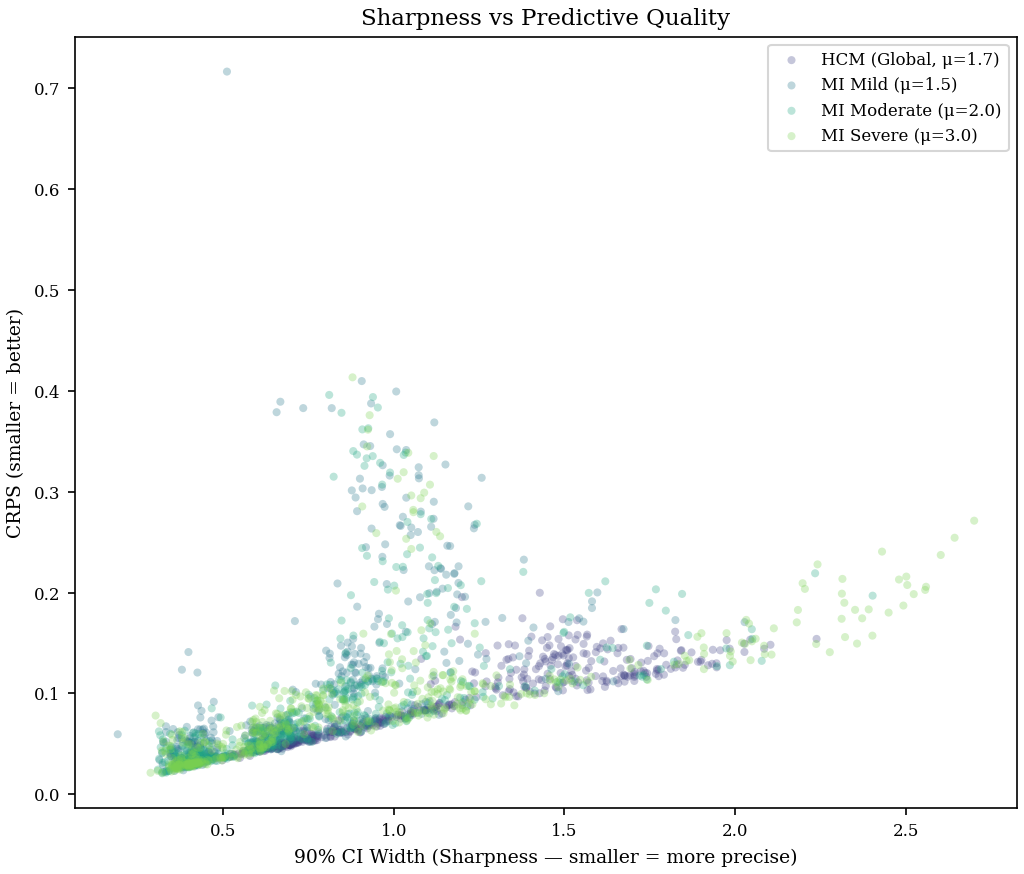

In [32]:
df_mc = df_errors[df_errors["method"] == "MCMC"].copy()
df_mc["scenario_display"] = df_mc["scenario"].map(SCENARIO_DISPLAY)

fig, ax = plt.subplots(figsize=(7, 6))
palette = sns.color_palette("viridis", len(SCENARIOS))

for s_idx, scenario in enumerate(SCENARIOS):
    df_s = df_mc[df_mc["scenario"] == scenario]
    ax.scatter(df_s["ci_width"], df_s["crps"],
               alpha=0.3, s=15, color=palette[s_idx],
               label=SCENARIO_DISPLAY[scenario], edgecolors="none")

ax.set_xlabel("90% CI Width (Sharpness — smaller = more precise)")
ax.set_ylabel("CRPS (smaller = better)")
ax.set_title("Sharpness vs Predictive Quality", fontsize=11)
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(Path(OUTPUT_DIR) / "sharpness_vs_crps.png")
print(f"💾 Saved: {OUTPUT_DIR}/sharpness_vs_crps.png")
plt.show()

---## 9. 结果汇总

In [33]:
# ── 列出所有生成的文件 ──
print("Generated Figures:")
print("=" * 60)
for f in sorted(Path(OUTPUT_DIR).glob("*.png")):
    print(f"  🖼️  {f.name:<50} ({f.stat().st_size/1024:.1f} KB)")

print(f"\nGenerated CSV files:")
print("=" * 60)
for f in sorted(Path(CSV_DIR).glob("*.csv")):
    n_rows = sum(1 for _ in open(f)) - 1
    print(f"  📄  {f.name:<50} ({n_rows} rows)")

Generated Figures:
  🖼️  bar_role_mcmc_crps.png                             (90.0 KB)
  🖼️  bar_role_pe_mse.png                                (76.8 KB)
  🖼️  boxplot_mcmc_ci_width.png                          (162.4 KB)
  🖼️  boxplot_mcmc_crps.png                              (117.0 KB)
  🖼️  boxplot_mcmc_interval_score.png                    (136.7 KB)
  🖼️  boxplot_pe_mse.png                                 (132.6 KB)
  🖼️  boxplot_ratio_mcmc.png                             (83.7 KB)
  🖼️  boxplot_ratio_point_estimate.png                   (102.0 KB)
  🖼️  boxplot_role_mcmc_crps.png                         (107.9 KB)
  🖼️  boxplot_role_point_estimate_mse.png                (109.5 KB)
  🖼️  calibration_heatmap.png                            (177.0 KB)
  🖼️  cross_error_MI_1.png                               (394.2 KB)
  🖼️  cross_error_MI_2.png                               (403.6 KB)
  🖼️  cross_error_MI_3.png                               (396.9 KB)
  🖼️  facet_role_MI_1_mcmc.png  

In [34]:
# ── 关键发现摘要 ──
print("\n" + "=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)

for scenario in SCENARIOS:
    df_s = df_paired[df_paired["scenario"] == scenario]
    if len(df_s) == 0:
        continue
    
    mcmc_crps_win = (df_s["mcmc_crps"] < df_s["pe_crps"]).mean()
    mean_crps_imp = df_s["crps_improvement"].mean()
    
    # Calibration
    cal_90 = df_calib[(df_calib["scenario"] == scenario) & (df_calib["credible_level"] == 0.90)]
    emp_cov = cal_90["covered"].mean() if len(cal_90) > 0 else np.nan
    
    # Mean CI width
    df_mc_s = df_errors[(df_errors["scenario"] == scenario) & (df_errors["method"] == "MCMC")]
    mean_width = df_mc_s["ci_width"].mean()
    
    print(f"\n{SCENARIO_DISPLAY[scenario]}:")
    print(f"  MCMC CRPS win rate:      {mcmc_crps_win*100:.1f}%")
    print(f"  Mean CRPS improvement:   {mean_crps_imp*100:.1f}%")
    print(f"  90% CI empirical coverage: {emp_cov:.3f} (ideal: 0.900)")
    print(f"  Mean 90% CI width:       {mean_width:.4f}")
    
    # Hardest region
    pe_region = df_errors[(df_errors["scenario"]==scenario) & (df_errors["method"]=="Point Estimate")]
    region_mse = pe_region.groupby("inferred_region")["mse"].mean()
    print(f"  Hardest region (PE MSE):  {region_mse.idxmax()} ({region_mse.max():.4f})")
    
    mc_region = df_errors[(df_errors["scenario"]==scenario) & (df_errors["method"]=="MCMC")]
    region_crps = mc_region.groupby("inferred_region")["crps"].mean()
    print(f"  Hardest region (MCMC CRPS): {region_crps.idxmax()} ({region_crps.max():.4f})")
    
    if scenario in LOCAL_MI_SCENARIOS:
        m, _ = build_cross_error_matrix(df_errors, scenario, "MCMC", "crps")
        diag_mean = np.nanmean(np.diag(m))
        off = m[~np.eye(N_REGIONS, dtype=bool)]
        print(f"  Cross-error diag/off-diag: {diag_mean/np.nanmean(off):.2f}x")


KEY FINDINGS SUMMARY

HCM (Global, μ=1.7):
  MCMC CRPS win rate:      36.2%
  Mean CRPS improvement:   -170.0%
  90% CI empirical coverage: 1.000 (ideal: 0.900)
  Mean 90% CI width:       1.1046
  Hardest region (PE MSE):  Inferior (0.1653)
  Hardest region (MCMC CRPS): Septal (0.1371)

MI Mild (μ=1.5):
  MCMC CRPS win rate:      41.4%
  Mean CRPS improvement:   -179.0%
  90% CI empirical coverage: 0.985 (ideal: 0.900)
  Mean 90% CI width:       0.7200
  Hardest region (PE MSE):  Inferior (0.0590)
  Hardest region (MCMC CRPS): Inferior (0.2376)
  Cross-error diag/off-diag: 1.13x

MI Moderate (μ=2.0):
  MCMC CRPS win rate:      46.0%
  Mean CRPS improvement:   -108.2%
  90% CI empirical coverage: 0.991 (ideal: 0.900)
  Mean 90% CI width:       0.7804
  Hardest region (PE MSE):  Inferior (0.0477)
  Hardest region (MCMC CRPS): Inferior (0.1863)
  Cross-error diag/off-diag: 1.22x

MI Severe (μ=3.0):
  MCMC CRPS win rate:      55.2%
  Mean CRPS improvement:   -83.7%
  90% CI empirical cove